<a href="https://colab.research.google.com/github/veridelisi/The-First-Bank-of-United-States-1791-1793-/blob/main/Employment_rates_by_educational_attainment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import pandas as pd
from io import StringIO
from google.colab import files

# ============================================================
# 1. OECD DATA (ALL COUNTRIES — NO EU FILTER)
# ============================================================

url = (
    "https://sdmx.oecd.org/public/rest/v1/data/"
    "OECD.ELS.IMD,DSD_MIG@DF_MIG_EMP_EDU,1.0/"
    "?startPeriod=2010"
    "&endPeriod=2024"
    "&dimensionAtObservation=AllDimensions"
)

headers = {"Accept": "text/csv"}

response = requests.get(url, headers=headers, timeout=180)
response.raise_for_status()

df = pd.read_csv(StringIO(response.text))

# ============================================================
# 2. EDUCATION LEVEL CODES
# ============================================================

education = {
    "_T": "Total",
    "ISCED11_0T2": "Low",
    "ISCED11_3_4": "Medium",
    "ISCED11_5T8": "Tertiary"
}

birth = {
    "FB": "Foreign",
    "NB": "Native"
}

# ============================================================
# 3. CLEAN AND FILTER THE DATA
# ============================================================

df["EDUCATION_LEV"] = df["EDUCATION_LEV"].astype(str).str.strip()
df["BIRTH_PLACE"] = df["BIRTH_PLACE"].astype(str).str.strip()
df["REF_AREA"] = df["REF_AREA"].astype(str).str.strip()

# Aggregate area codes to exclude (not individual countries)
excluded_areas = ["EU27", "EU27_2020", "EU28"]

# Select:
# - Employment rate
# - Total population (male + female)
# - Foreign-born and native-born
# - Total + three education levels
# - ALL countries present in the dataset, excluding EU aggregate codes

filtered = df[
    (df["MEASURE"] == "EMP_WAP") &
    (df["SEX"] == "_T") &
    (df["BIRTH_PLACE"].isin(["FB", "NB"])) &
    (df["EDUCATION_LEV"].isin(education.keys())) &
    (~df["REF_AREA"].isin(excluded_areas))
].copy()

excluded_found = sorted(set(excluded_areas) & set(df["REF_AREA"].unique()))
print(f"Excluded aggregate area codes found in raw data and removed: {excluded_found}")

# --- THESE TWO LINES ARE THE MISSING PIECE ---
filtered["EDU"] = filtered["EDUCATION_LEV"].map(education)
filtered["BIRTH"] = filtered["BIRTH_PLACE"].map(birth)
# -----------------------------------------------

# ============================================================
# 4. CONVERT TO COUNTRY-YEAR WIDE FORMAT
# ============================================================

result = filtered.pivot_table(
    index=["REF_AREA", "TIME_PERIOD"],
    columns=["EDU", "BIRTH"],
    values="OBS_VALUE",
    aggfunc="first"
).reset_index()

result.columns = [
    "_".join([str(x) for x in col if str(x) != ""]).strip("_")
    if isinstance(col, tuple)
    else col
    for col in result.columns
]

# ============================================================
# 5. SELECT AND ORDER THE 8 EMPLOYMENT VARIABLES
# ============================================================

columns = [
    "REF_AREA",
    "TIME_PERIOD",

    "Total_Foreign",
    "Total_Native",

    "Low_Foreign",
    "Low_Native",

    "Medium_Foreign",
    "Medium_Native",

    "Tertiary_Foreign",
    "Tertiary_Native"
]

# Some value columns may not exist at all if no country reported them —
# add any missing ones as all-NaN so the structure stays consistent.
for col in columns:
    if col not in result.columns:
        result[col] = pd.NA

result = result[columns]

# ============================================================
# 6. ROUND EMPLOYMENT RATES TO ONE DECIMAL PLACE
# ============================================================

value_columns = columns[2:]
result[value_columns] = result[value_columns].apply(pd.to_numeric, errors="coerce").round(1)

result = result.sort_values(["REF_AREA", "TIME_PERIOD"]).reset_index(drop=True)

# ============================================================
# 7. DISPLAY THE FIRST 30 RECORDS
# ============================================================

print("Number of country-year observations:", len(result))
print("Number of unique countries:", result["REF_AREA"].nunique())
print("\nFinal columns:")
print(result.columns.tolist())

display(result.head(30))

# ============================================================
# 8. NaN SUMMARY BY EDUCATION CATEGORY (Total, Low, Medium, Tertiary)
# For each category, combines its Foreign + Native columns and reports
# the missing-value count and percentage within that category's own cells.
# Formatted as a table suitable for direct use in a paper.
# ============================================================

categories = ["Total", "Low", "Medium", "Tertiary"]
nan_summary_rows = []

for cat in categories:
    cols = [f"{cat}_Foreign", f"{cat}_Native"]
    cat_data = result[cols]

    total_cells = cat_data.size
    missing_cells = cat_data.isna().sum().sum()
    pct_missing = (missing_cells / total_cells) * 100

    nan_summary_rows.append({
        "Category": cat,
        "Total Cells": total_cells,
        "Missing (NaN)": missing_cells,
        "Missing (%)": round(pct_missing, 1)
    })

nan_summary = pd.DataFrame(nan_summary_rows)

print("\n" + "=" * 60)
print("Missing Value Summary by Education Category")
print("=" * 60)
display(nan_summary)

# ============================================================
# 9. LIST OF COUNTRIES IN REF_AREA
# ============================================================

all_countries = sorted(result["REF_AREA"].unique())
print(f"\nTotal number of countries in REF_AREA: {len(all_countries)}")
print(", ".join(all_countries))

Excluded aggregate area codes found in raw data and removed: ['EU27', 'EU27_2020', 'EU28']
Number of country-year observations: 335
Number of unique countries: 38

Final columns:
['REF_AREA', 'TIME_PERIOD', 'Total_Foreign', 'Total_Native', 'Low_Foreign', 'Low_Native', 'Medium_Foreign', 'Medium_Native', 'Tertiary_Foreign', 'Tertiary_Native']


,REF_AREA,TIME_PERIOD,Total_Foreign,Total_Native,Low_Foreign,Low_Native,Medium_Foreign,Medium_Native,Tertiary_Foreign,Tertiary_Native
0,AUS,2015,72.3,77.2,NaN,NaN,NaN,NaN,NaN,NaN
1,AUS,2016,72.6,77.6,NaN,NaN,NaN,NaN,NaN,NaN
2,AUS,2017,73.7,78.1,NaN,NaN,NaN,NaN,NaN,NaN
3,AUS,2018,74.5,78.6,NaN,NaN,NaN,NaN,NaN,NaN
4,AUS,2019,72.1,75.4,NaN,NaN,NaN,NaN,NaN,NaN
5,AUS,2020,70.7,73.4,NaN,NaN,NaN,NaN,NaN,NaN
6,AUS,2021,73.8,75.2,NaN,NaN,NaN,NaN,NaN,NaN
7,AUS,2022,77.0,77.1,NaN,NaN,NaN,NaN,NaN,NaN
8,AUS,2023,77.5,77.3,NaN,NaN,NaN,NaN,NaN,NaN
9,AUS,2024,77.3,77.2,NaN,NaN,NaN,NaN,NaN,NaN



Missing Value Summary by Education Category


,Category,Total Cells,Missing (NaN),Missing (%)
0,Total,670,2,0.3
1,Low,670,68,10.1
2,Medium,670,46,6.9
3,Tertiary,670,46,6.9



Total number of countries in REF_AREA: 38
AUS, AUT, BEL, CAN, CHE, CHL, COL, CRI, CZE, DEU, DNK, ESP, EST, FIN, FRA, GBR, GRC, HRV, HUN, IRL, ISL, ISR, ITA, KOR, LTU, LUX, LVA, MEX, NLD, NOR, NZL, POL, PRT, SVK, SVN, SWE, TUR, USA


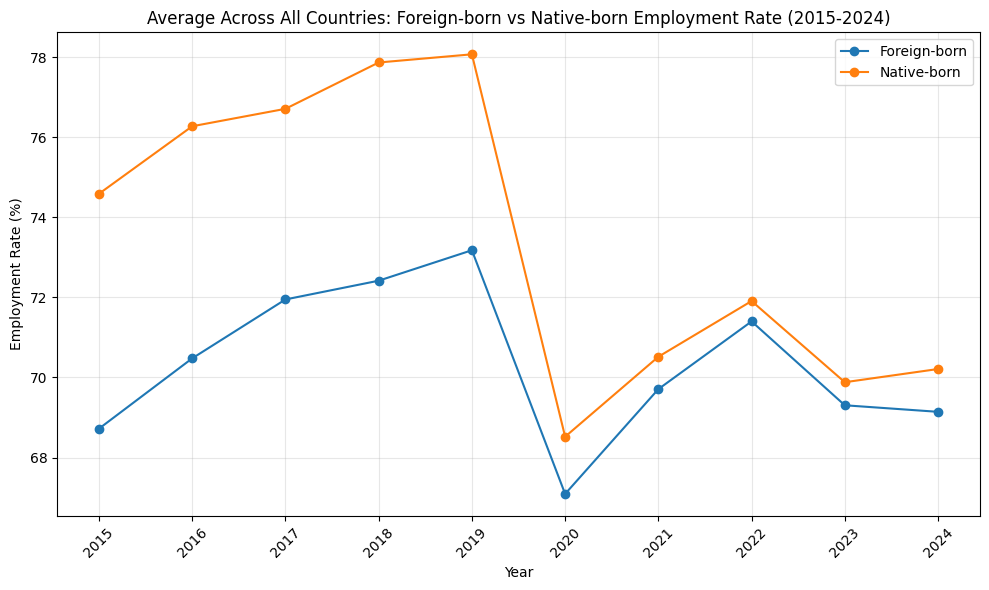

Methodology — Chart 1:
For each year, the employment rate is averaged across all countries that
reported a value for that year. Countries with a missing (NaN) value in a
given year are excluded from that year's average only — they are not treated
as zero and do not drag the average down. Countries contributing per year:
             Total_Foreign  Total_Native
TIME_PERIOD                             
2015                    33            33
2016                    31            31
2017                    31            31
2018                    30            30
2019                    31            31
2020                    35            35
2021                    35            35
2022                    35            35
2023                    37            37
2024                    36            36



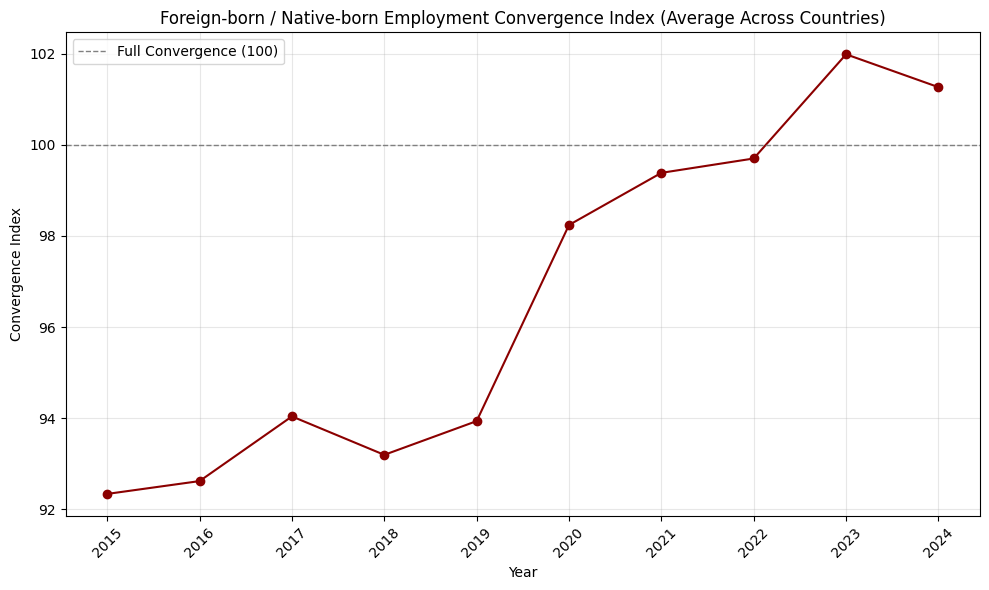

Methodology — Chart 2:
The convergence index is computed per country-year as (Foreign / Native) * 100.
Rows where Native is 0 or NaN produce an undefined ratio (NaN or inf); these are
converted to NaN and excluded before averaging, so they cannot bias the yearly mean.
The plotted line is the mean of the index across all countries with a valid value
in that year. Countries contributing per year:
TIME_PERIOD
2015    33
2016    31
2017    31
2018    30
2019    31
2020    35
2021    35
2022    35
2023    37
2024    36
Name: Convergence_Index, dtype: int64



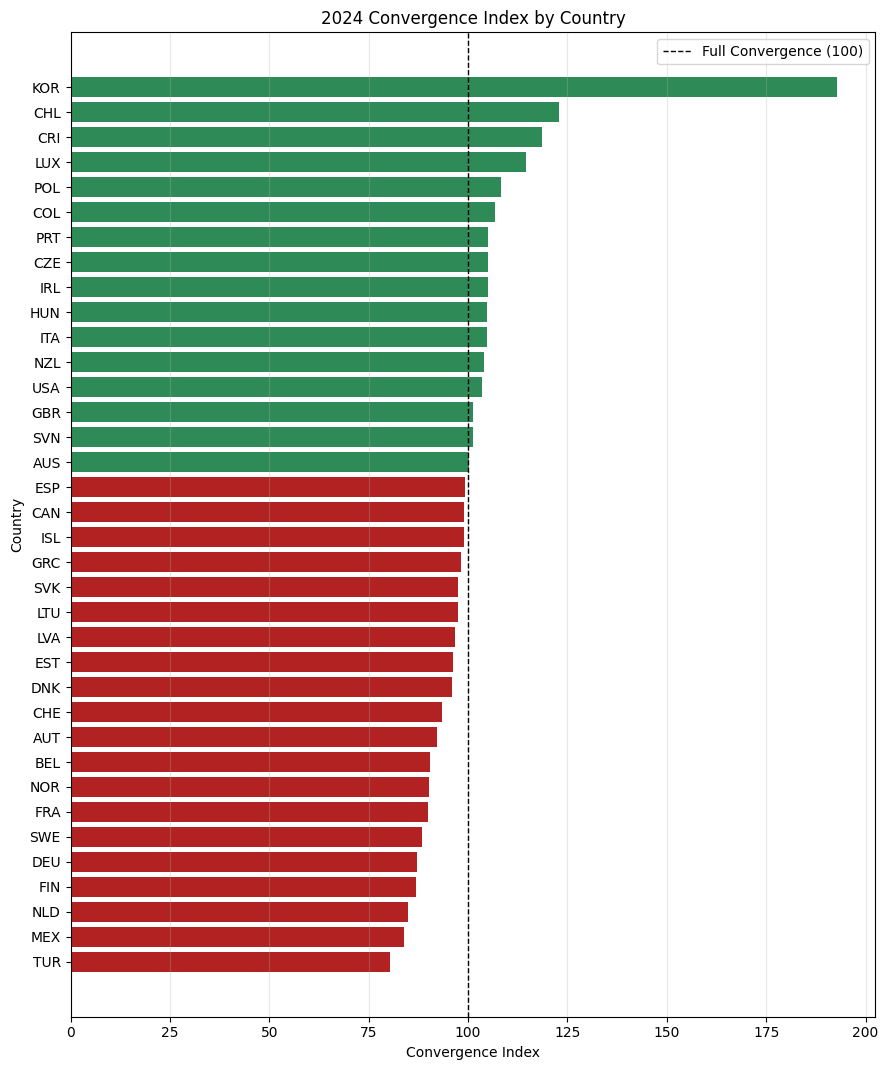

Methodology — Chart 3:
Shows each country's 2024 convergence index. Countries with a missing or
undefined value for 2024 are excluded from the chart entirely (not shown as 0),
so the bars reflect only countries with valid data for that year.
Countries shown: 36 out of 38 total in the dataset.


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 0. YEAR FILTER (2015-2024)
# ============================================================

result["TIME_PERIOD"] = result["TIME_PERIOD"].astype(int)
res = result[(result["TIME_PERIOD"] >= 2015) & (result["TIME_PERIOD"] <= 2024)].copy()

# ============================================================
# 1. CHART: AVERAGE ACROSS ALL COUNTRIES (Total_Foreign vs Total_Native)
# NOTE: pandas' .mean() ignores NaN by default (skipna=True), so
# countries with missing values for a given year are simply excluded
# from that year's average rather than pulling it toward zero.
# ============================================================

yearly_avg = res.groupby("TIME_PERIOD")[["Total_Foreign", "Total_Native"]].mean()

# how many countries actually contributed to each year's average
coverage_total = res.groupby("TIME_PERIOD")[["Total_Foreign", "Total_Native"]].apply(
    lambda d: d.notna().sum()
)

plt.figure(figsize=(10, 6))
plt.plot(yearly_avg.index, yearly_avg["Total_Foreign"], marker="o", label="Foreign-born")
plt.plot(yearly_avg.index, yearly_avg["Total_Native"], marker="o", label="Native-born")
plt.title("Average Across All Countries: Foreign-born vs Native-born Employment Rate (2015-2024)")
plt.xlabel("Year")
plt.ylabel("Employment Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(yearly_avg.index, rotation=45)
plt.tight_layout()
plt.show()

print("Methodology — Chart 1:")
print("For each year, the employment rate is averaged across all countries that")
print("reported a value for that year. Countries with a missing (NaN) value in a")
print("given year are excluded from that year's average only — they are not treated")
print("as zero and do not drag the average down. Countries contributing per year:")
print(coverage_total)
print()

# ============================================================
# 2. CONVERGENCE INDEX
# Index = (Foreign / Native) * 100
# 100  -> full convergence (foreign = native)
# <100 -> foreign-born lag behind native-born
# >100 -> foreign-born exceed native-born
#
# NOTE: if Native = 0 or NaN, the ratio becomes NaN/inf and would
# distort the average if left in. These cases are explicitly removed
# before the index is averaged across countries.
# ============================================================

ratio = res["Total_Foreign"] / res["Total_Native"].replace(0, np.nan)
ratio = ratio.replace([np.inf, -np.inf], np.nan)
res["Convergence_Index"] = ratio * 100

index_by_year = res.groupby("TIME_PERIOD")["Convergence_Index"].mean()
coverage_index = res.groupby("TIME_PERIOD")["Convergence_Index"].apply(lambda s: s.notna().sum())

plt.figure(figsize=(10, 6))
plt.plot(index_by_year.index, index_by_year.values, marker="o", color="darkred")
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("Foreign-born / Native-born Employment Convergence Index (Average Across Countries)")
plt.xlabel("Year")
plt.ylabel("Convergence Index")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(index_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

print("Methodology — Chart 2:")
print("The convergence index is computed per country-year as (Foreign / Native) * 100.")
print("Rows where Native is 0 or NaN produce an undefined ratio (NaN or inf); these are")
print("converted to NaN and excluded before averaging, so they cannot bias the yearly mean.")
print("The plotted line is the mean of the index across all countries with a valid value")
print("in that year. Countries contributing per year:")
print(coverage_index)
print()

# ============================================================
# 3. 2024: CONVERGENCE INDEX BY COUNTRY (Horizontal Bar Chart)
# Countries with no valid index value in 2024 (NaN) are dropped
# rather than shown as zero.
# ============================================================

data_2024 = res[res["TIME_PERIOD"] == 2024][["REF_AREA", "Convergence_Index"]].dropna()
data_2024 = data_2024.sort_values("Convergence_Index")

plt.figure(figsize=(9, max(6, len(data_2024) * 0.3)))
colors = ["firebrick" if v < 100 else "seagreen" for v in data_2024["Convergence_Index"]]
plt.barh(data_2024["REF_AREA"], data_2024["Convergence_Index"], color=colors)
plt.axvline(100, color="black", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("2024 Convergence Index by Country")
plt.xlabel("Convergence Index")
plt.ylabel("Country")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology — Chart 3:")
print(f"Shows each country's 2024 convergence index. Countries with a missing or")
print(f"undefined value for 2024 are excluded from the chart entirely (not shown as 0),")
print(f"so the bars reflect only countries with valid data for that year.")
print(f"Countries shown: {len(data_2024)} out of {res['REF_AREA'].nunique()} total in the dataset.")

Rows after filtering to SEX=_T, EDUCATION_LEV=_Z, BIRTH_COUNTRY=W: 440
Countries with a 'W' total row: 37


,REF_AREA,TIME_PERIOD,Foreign_Born_Population
0,AUS,2010,5881360.0
1,AUS,2011,6018180.0
2,AUS,2012,6214010.0
3,AUS,2013,6408740.0
4,AUS,2014,6570240.0
5,AUS,2015,6729730.0
6,AUS,2016,6912110.0
7,AUS,2017,7142030.0
8,AUS,2018,7346520.0
9,AUS,2019,7549660.0



Countries missing a foreign-born population weight for at least one year: ['CAN', 'COL', 'CRI', 'GBR', 'GRC', 'HRV', 'IRL', 'KOR', 'MEX', 'NZL', 'POL', 'PRT']

Equal-weighted vs. Foreign-born-population-weighted Convergence Index


,Equal-weighted Index,Foreign-born-population-weighted Index
2015,92.34,93.52
2016,92.62,93.61
2017,94.04,93.86
2018,93.20,94.18
2019,93.94,96.11
2020,98.24,96.56
2021,99.38,98.40
2022,99.70,99.01
2023,101.98,98.52
2024,101.26,97.98


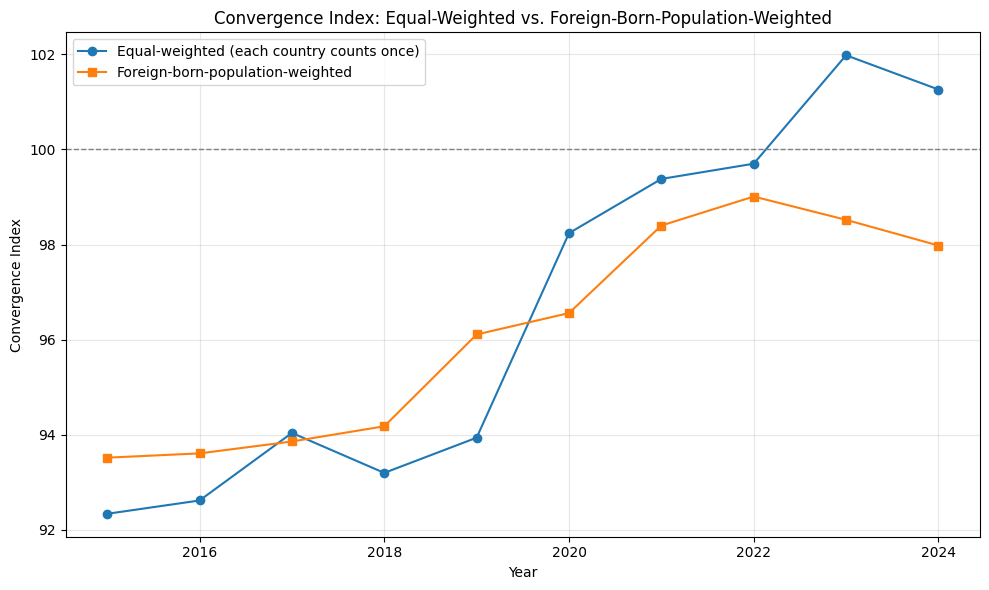

Methodology:
The population-weighted index gives each country a weight equal to its share of
the total foreign-born population (BIRTH_COUNTRY='W', i.e. the sum across all
countries of birth, from the OECD DF_MIG_POPF dataflow) among all countries with
valid data in that year; weights are recomputed annually as populations change.
This reflects the experience of a 'typical migrant' across the sample, rather than
a 'typical country' — large-immigration countries pull the weighted average toward
their own value more than small-immigration countries do. Countries with a missing
population weight for a given year are excluded from that year's weighted average.


In [3]:
import requests
import pandas as pd
from io import StringIO
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. FETCH FOREIGN-BORN POPULATION STOCK (DF_MIG_POPF)
# ============================================================

url_popf = (
    "https://sdmx.oecd.org/public/rest/v1/data/"
    "OECD.ELS.IMD,DSD_MIG_F@DF_MIG_POPF,1.0/"
    "?startPeriod=2010"
    "&endPeriod=2024"
    "&dimensionAtObservation=AllDimensions"
)

headers = {"Accept": "text/csv"}

response_popf = requests.get(url_popf, headers=headers, timeout=180)
response_popf.raise_for_status()

df_popf = pd.read_csv(StringIO(response_popf.text))

df_popf["REF_AREA"] = df_popf["REF_AREA"].astype(str).str.strip()
df_popf["BIRTH_COUNTRY"] = df_popf["BIRTH_COUNTRY"].astype(str).str.strip()
df_popf["SEX"] = df_popf["SEX"].astype(str).str.strip()
df_popf["EDUCATION_LEV"] = df_popf["EDUCATION_LEV"].astype(str).str.strip()

# ============================================================
# 2. FILTER TO TOTAL FOREIGN-BORN POPULATION PER COUNTRY-YEAR
# SEX=_T (both sexes), EDUCATION_LEV=_Z (not applicable at this level),
# BIRTH_COUNTRY="W" (World = total across all countries of birth)
# ============================================================

foreign_pop = df_popf[
    (df_popf["SEX"] == "_T") &
    (df_popf["EDUCATION_LEV"] == "_Z") &
    (df_popf["BIRTH_COUNTRY"] == "W")
].copy()

print(f"Rows after filtering to SEX=_T, EDUCATION_LEV=_Z, BIRTH_COUNTRY=W: {len(foreign_pop)}")
print(f"Countries with a 'W' total row: {foreign_pop['REF_AREA'].nunique()}")

foreign_pop = (
    foreign_pop
    .groupby(["REF_AREA", "TIME_PERIOD"])["OBS_VALUE"]
    .first()
    .reset_index()
    .rename(columns={"OBS_VALUE": "Foreign_Born_Population"})
)

foreign_pop["TIME_PERIOD"] = foreign_pop["TIME_PERIOD"].astype(int)

display(foreign_pop.head(15))

# ============================================================
# 3. MERGE WITH THE EXISTING EMPLOYMENT `result` TABLE
# ============================================================

result["TIME_PERIOD"] = result["TIME_PERIOD"].astype(int)

res_weighted = result.merge(foreign_pop, on=["REF_AREA", "TIME_PERIOD"], how="left")

missing_pop = sorted(res_weighted[res_weighted["Foreign_Born_Population"].isna()]["REF_AREA"].unique())
print(f"\nCountries missing a foreign-born population weight for at least one year: {missing_pop}")

# ============================================================
# 4. FOREIGN-BORN-POPULATION-WEIGHTED CONVERGENCE INDEX
# Weight = each country's share of the total foreign-born population
# across all countries with valid data, recomputed for each year.
# ============================================================

ratio = res_weighted["Total_Foreign"] / res_weighted["Total_Native"].replace(0, np.nan)
res_weighted["Convergence_Index"] = ratio.replace([np.inf, -np.inf], np.nan) * 100

def weighted_avg_by_year(df, value_col, weight_col):
    out = {}
    for year, group in df.groupby("TIME_PERIOD"):
        valid = group.dropna(subset=[value_col, weight_col])
        valid = valid[valid[weight_col] > 0]
        if len(valid) == 0 or valid[weight_col].sum() == 0:
            out[year] = np.nan
            continue
        out[year] = np.average(valid[value_col], weights=valid[weight_col])
    return pd.Series(out).sort_index()

equal_weighted_index = res_weighted.groupby("TIME_PERIOD")["Convergence_Index"].mean()
pop_weighted_index = weighted_avg_by_year(res_weighted, "Convergence_Index", "Foreign_Born_Population")

comparison = pd.DataFrame({
    "Equal-weighted Index": equal_weighted_index,
    "Foreign-born-population-weighted Index": pop_weighted_index
}).round(2)

print("\n" + "=" * 70)
print("Equal-weighted vs. Foreign-born-population-weighted Convergence Index")
print("=" * 70)
display(comparison)

# ============================================================
# 5. PLOT: EQUAL-WEIGHTED VS POPULATION-WEIGHTED INDEX
# ============================================================

plt.figure(figsize=(10, 6))
plt.plot(comparison.index, comparison["Equal-weighted Index"], marker="o",
          label="Equal-weighted (each country counts once)")
plt.plot(comparison.index, comparison["Foreign-born-population-weighted Index"], marker="s",
          label="Foreign-born-population-weighted")
plt.axhline(100, color="gray", linestyle="--", linewidth=1)
plt.title("Convergence Index: Equal-Weighted vs. Foreign-Born-Population-Weighted")
plt.xlabel("Year")
plt.ylabel("Convergence Index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Methodology:")
print("The population-weighted index gives each country a weight equal to its share of")
print("the total foreign-born population (BIRTH_COUNTRY='W', i.e. the sum across all")
print("countries of birth, from the OECD DF_MIG_POPF dataflow) among all countries with")
print("valid data in that year; weights are recomputed annually as populations change.")
print("This reflects the experience of a 'typical migrant' across the sample, rather than")
print("a 'typical country' — large-immigration countries pull the weighted average toward")
print("their own value more than small-immigration countries do. Countries with a missing")
print("population weight for a given year are excluded from that year's weighted average.")

,Country,Foreign-born employment rate (2024),Native-born employment rate (2024),Convergence index (2024),Annual trend,Years available,Country type
0,ESP,65.7,66.2,99.2,0.77,10.0,Converging employment gap
1,CAN,74.2,74.9,99.1,0.41,6.0,Converging employment gap
2,ISL,84.7,85.5,99.1,0.17,10.0,Converging employment gap
3,GRC,62.2,63.4,98.1,0.88,10.0,Converging employment gap
4,SVK,70.6,72.4,97.5,1.75,10.0,Converging employment gap
5,LTU,71.8,73.7,97.4,0.98,10.0,Converging employment gap
6,LVA,69.0,71.4,96.6,1.55,10.0,Converging employment gap
7,EST,73.3,76.1,96.3,1.30,10.0,Converging employment gap
8,DNK,74.5,77.6,96.0,1.66,10.0,Converging employment gap
9,CHE,76.9,82.4,93.3,0.36,10.0,Converging employment gap



Number of countries in each group:


,Country type,Number of countries
0,Converging employment gap,18
1,Strengthening migrant advantage,14
2,Narrowing migrant advantage,1
3,Widening integration gap,1


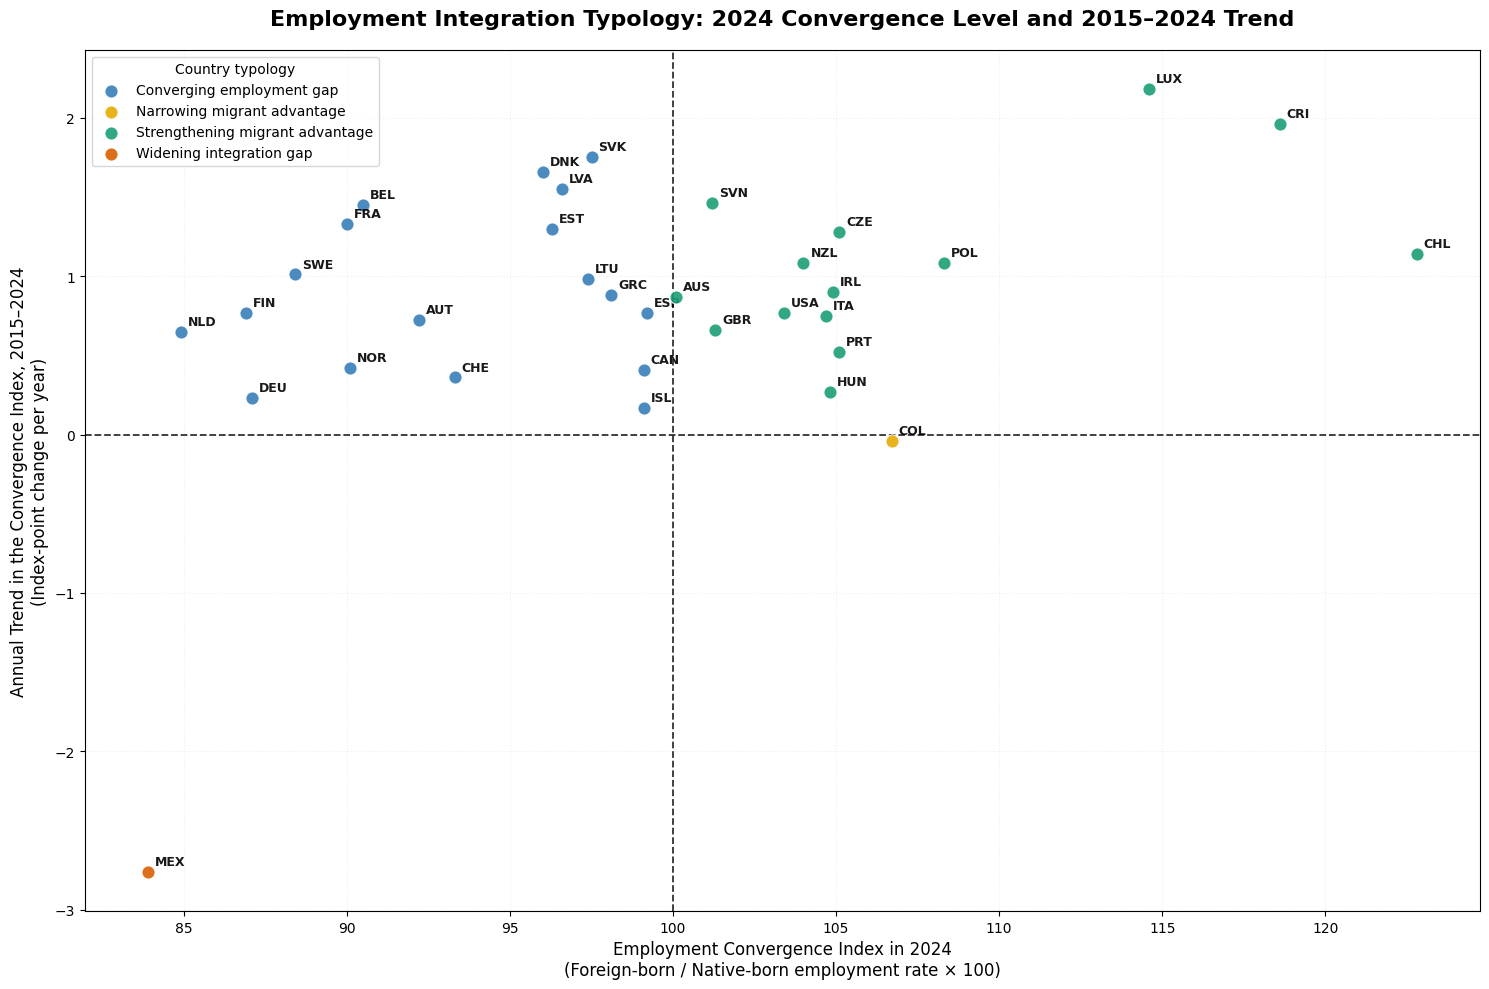


Methodological note:
The 2024 convergence index is calculated as the foreign-born employment rate divided by the native-born employment rate, multiplied by 100. A value of 100 indicates equal employment rates. The historical trend is the country-specific OLS slope estimated using all available annual observations between 2015 and 2024. Positive slopes indicate an increase in the foreign-born employment rate relative to the native-born rate.


,2024 level,2015–2024 trend,Country type,Countries,Number of countries
0,High (≥100),Increasing,Strengthening migrant advantage,"AUS, CHL, CRI, CZE, GBR, HUN, IRL, ITA, LUX, N...",14
1,High (≥100),Decreasing,Narrowing migrant advantage,COL,1
2,Low (<100),Increasing,Converging country,"AUT, BEL, CAN, CHE, DEU, DNK, ESP, EST, FIN, F...",18
3,Low (<100),Decreasing,Widening integration gap,MEX,1


In [4]:
# ============================================================
# 2. TWO-DIMENSIONAL COUNTRY TYPOLOGY
# 2024 convergence level and 2015–2024 trend
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

typology_data = res.copy()

# Ensure numeric values
numeric_columns = [
    "TIME_PERIOD",
    "Total_Foreign",
    "Total_Native"
]

for column in numeric_columns:
    typology_data[column] = pd.to_numeric(
        typology_data[column],
        errors="coerce"
    )

# Remove observations without both employment rates
typology_data = typology_data.dropna(
    subset=[
        "REF_AREA",
        "TIME_PERIOD",
        "Total_Foreign",
        "Total_Native"
    ]
).copy()

# Exclude invalid denominators
typology_data = typology_data[
    typology_data["Total_Native"] > 0
].copy()

# Country-year employment convergence index
typology_data["Convergence_Index"] = (
    typology_data["Total_Foreign"] /
    typology_data["Total_Native"] * 100
)

typology_data = typology_data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna(
    subset=["Convergence_Index"]
)

# ============================================================
# 3. ESTIMATE THE 2015–2024 TREND FOR EACH COUNTRY
# ============================================================

def calculate_country_trend(country_data):
    """
    Estimate the annual linear trend in the convergence index.
    The slope shows the average annual change in index points.
    """

    country_data = (
        country_data
        .dropna(subset=["TIME_PERIOD", "Convergence_Index"])
        .sort_values("TIME_PERIOD")
    )

    number_of_years = country_data["TIME_PERIOD"].nunique()

    # Require at least two different years
    if number_of_years < 2:
        return pd.Series({
            "Trend_Slope": np.nan,
            "Years_Available": number_of_years,
            "First_Year": np.nan,
            "Last_Year": np.nan
        })

    slope = np.polyfit(
        country_data["TIME_PERIOD"],
        country_data["Convergence_Index"],
        1
    )[0]

    return pd.Series({
        "Trend_Slope": slope,
        "Years_Available": number_of_years,
        "First_Year": country_data["TIME_PERIOD"].min(),
        "Last_Year": country_data["TIME_PERIOD"].max()
    })


country_trends = (
    typology_data
    .groupby("REF_AREA")
    .apply(calculate_country_trend, include_groups=False)
    .reset_index()
)

# ============================================================
# 4. EXTRACT THE 2024 CONVERGENCE LEVEL
# ============================================================

level_2024 = (
    typology_data[
        typology_data["TIME_PERIOD"] == 2024
    ][
        [
            "REF_AREA",
            "Total_Foreign",
            "Total_Native",
            "Convergence_Index"
        ]
    ]
    .rename(
        columns={
            "Total_Foreign": "Foreign_Employment_2024",
            "Total_Native": "Native_Employment_2024",
            "Convergence_Index": "Convergence_2024"
        }
    )
)

# Merge 2024 levels with historical trends
country_typology = level_2024.merge(
    country_trends,
    on="REF_AREA",
    how="inner"
)

country_typology = country_typology.dropna(
    subset=["Convergence_2024", "Trend_Slope"]
).copy()

# Optional reliability requirement:
# Keep countries with at least five valid annual observations
country_typology = country_typology[
    country_typology["Years_Available"] >= 5
].copy()

# ============================================================
# 5. CLASSIFY COUNTRIES INTO FOUR GROUPS
# ============================================================

def classify_country(row):

    level = row["Convergence_2024"]
    trend = row["Trend_Slope"]

    if level >= 100 and trend >= 0:
        return "Strengthening migrant advantage"

    elif level >= 100 and trend < 0:
        return "Narrowing migrant advantage"

    elif level < 100 and trend >= 0:
        return "Converging employment gap"

    else:
        return "Widening integration gap"


country_typology["Country_Type"] = country_typology.apply(
    classify_country,
    axis=1
)

# Round only the displayed results
country_typology["Convergence_2024"] = (
    country_typology["Convergence_2024"].round(1)
)

country_typology["Trend_Slope"] = (
    country_typology["Trend_Slope"].round(2)
)

country_typology["Foreign_Employment_2024"] = (
    country_typology["Foreign_Employment_2024"].round(1)
)

country_typology["Native_Employment_2024"] = (
    country_typology["Native_Employment_2024"].round(1)
)

# Sort from the highest to the lowest 2024 convergence level
country_typology = (
    country_typology
    .sort_values(
        ["Country_Type", "Convergence_2024"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

# ============================================================
# 6. DISPLAY THE CLASSIFICATION TABLE
# ============================================================

classification_table = country_typology[
    [
        "REF_AREA",
        "Foreign_Employment_2024",
        "Native_Employment_2024",
        "Convergence_2024",
        "Trend_Slope",
        "Years_Available",
        "Country_Type"
    ]
].rename(
    columns={
        "REF_AREA": "Country",
        "Foreign_Employment_2024": "Foreign-born employment rate (2024)",
        "Native_Employment_2024": "Native-born employment rate (2024)",
        "Convergence_2024": "Convergence index (2024)",
        "Trend_Slope": "Annual trend",
        "Years_Available": "Years available",
        "Country_Type": "Country type"
    }
)

display(classification_table)

print("\nNumber of countries in each group:")
display(
    country_typology["Country_Type"]
    .value_counts()
    .rename_axis("Country type")
    .reset_index(name="Number of countries")
)

# ============================================================
# 7. DRAW THE TWO-DIMENSIONAL TYPOLOGY
# ============================================================

colors = {
    "Strengthening migrant advantage": "#1B9E77",
    "Narrowing migrant advantage": "#E6AB02",
    "Converging employment gap": "#377EB8",
    "Widening integration gap": "#D95F02"
}

fig, ax = plt.subplots(figsize=(15, 10))

for country_type, group in country_typology.groupby("Country_Type"):

    ax.scatter(
        group["Convergence_2024"],
        group["Trend_Slope"],
        s=90,
        color=colors[country_type],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.9,
        label=country_type,
        zorder=3
    )

    for _, row in group.iterrows():
        ax.annotate(
            row["REF_AREA"],
            (
                row["Convergence_2024"],
                row["Trend_Slope"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            alpha=0.9
        )

# Reference lines
ax.axvline(
    x=100,
    color="black",
    linestyle="--",
    linewidth=1.3,
    alpha=0.8
)

ax.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1.3,
    alpha=0.8
)

ax.set_title(
    "Employment Integration Typology: "
    "2024 Convergence Level and 2015–2024 Trend",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Employment Convergence Index in 2024\n"
    "(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)

ax.set_ylabel(
    "Annual Trend in the Convergence Index, 2015–2024\n"
    "(Index-point change per year)",
    fontsize=12
)

ax.grid(
    alpha=0.20,
    linestyle=":"
)

ax.legend(
    title="Country typology",
    loc="best",
    frameon=True
)

plt.tight_layout()
plt.show()

# ============================================================
# 8. METHODOLOGICAL NOTE
# ============================================================

print(
    "\nMethodological note:\n"
    "The 2024 convergence index is calculated as the foreign-born "
    "employment rate divided by the native-born employment rate, "
    "multiplied by 100. A value of 100 indicates equal employment "
    "rates. The historical trend is the country-specific OLS slope "
    "estimated using all available annual observations between "
    "2015 and 2024. Positive slopes indicate an increase in the "
    "foreign-born employment rate relative to the native-born rate."
)

# ============================================================
# SUMMARY TYPOLOGY TABLE
# ============================================================

type_order = [
    "Strengthening migrant advantage",
    "Narrowing migrant advantage",
    "Converging country",
    "Widening integration gap"
]

# Use the desired country-type labels
def classify_country(row):
    if row["Convergence_2024"] >= 100 and row["Trend_Slope"] >= 0:
        return "Strengthening migrant advantage"

    elif row["Convergence_2024"] >= 100 and row["Trend_Slope"] < 0:
        return "Narrowing migrant advantage"

    elif row["Convergence_2024"] < 100 and row["Trend_Slope"] >= 0:
        return "Converging country"

    else:
        return "Widening integration gap"


country_typology["Country_Type"] = country_typology.apply(
    classify_country,
    axis=1
)

# Create country lists for each group
country_lists = (
    country_typology
    .sort_values("REF_AREA")
    .groupby("Country_Type")["REF_AREA"]
    .apply(lambda x: ", ".join(x))
    .to_dict()
)

country_counts = (
    country_typology["Country_Type"]
    .value_counts()
    .to_dict()
)

# Create the four-row typology table
typology_table = pd.DataFrame({
    "2024 level": [
        "High (≥100)",
        "High (≥100)",
        "Low (<100)",
        "Low (<100)"
    ],

    "2015–2024 trend": [
        "Increasing",
        "Decreasing",
        "Increasing",
        "Decreasing"
    ],

    "Country type": type_order
})

# Add actual countries and their number
typology_table["Countries"] = typology_table["Country type"].map(
    country_lists
).fillna("None")

typology_table["Number of countries"] = (
    typology_table["Country type"]
    .map(country_counts)
    .fillna(0)
    .astype(int)
)

display(typology_table)

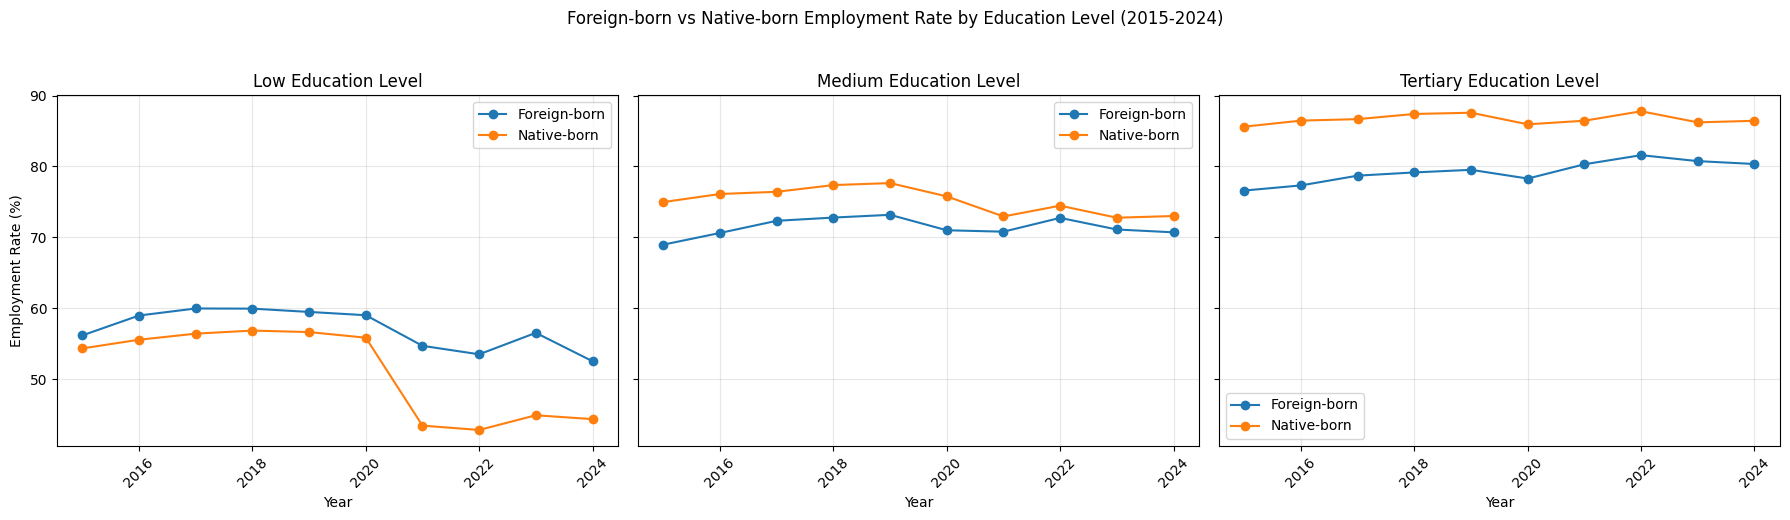

Methodology — Chart 1:
For each education level and year, the employment rate is averaged across all
countries that reported a value for that year. pandas' .mean() ignores NaN by
default (skipna=True), so a country missing data for a given year/category is
simply left out of that year's average rather than treated as zero.
Countries contributing per year (per category):

Low:
             Low_Foreign  Low_Native
TIME_PERIOD                         
2015                  28          31
2016                  28          30
2017                  28          30
2018                  27          29
2019                  28          30
2020                  31          33
2021                  30          32
2022                  28          29
2023                  29          34
2024                  33          34

Medium:
             Medium_Foreign  Medium_Native
TIME_PERIOD                               
2015                     31             31
2016                     30            

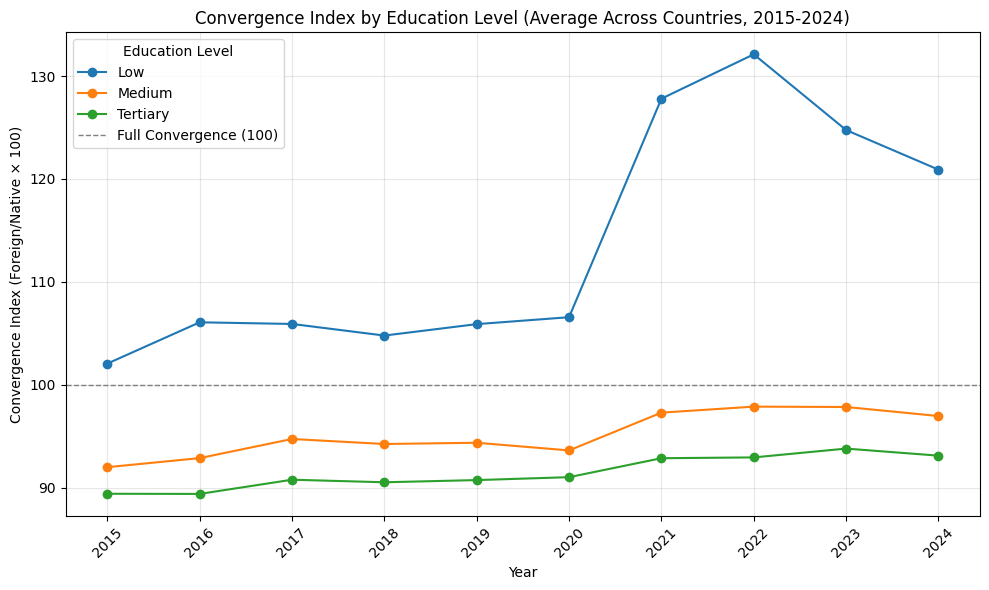

Methodology — Chart 2:
The convergence index is computed per country-year-category as
(Foreign / Native) * 100. Rows where Native is 0 or NaN produce an undefined
ratio; these are converted to NaN and dropped before averaging, so they do not
distort the yearly mean. Each plotted line is the mean of the index across all
countries with a valid value in that year, for that education level.
Number of countries contributing to the index, per year and category:
             Low  Medium  Tertiary
TIME_PERIOD                       
2015          28      31        31
2016          28      30        30
2017          28      30        30
2018          27      29        29
2019          28      30        30
2020          31      33        33
2021          30      32        32
2022          28      29        29
2023          29      34        34
2024          33      34        34



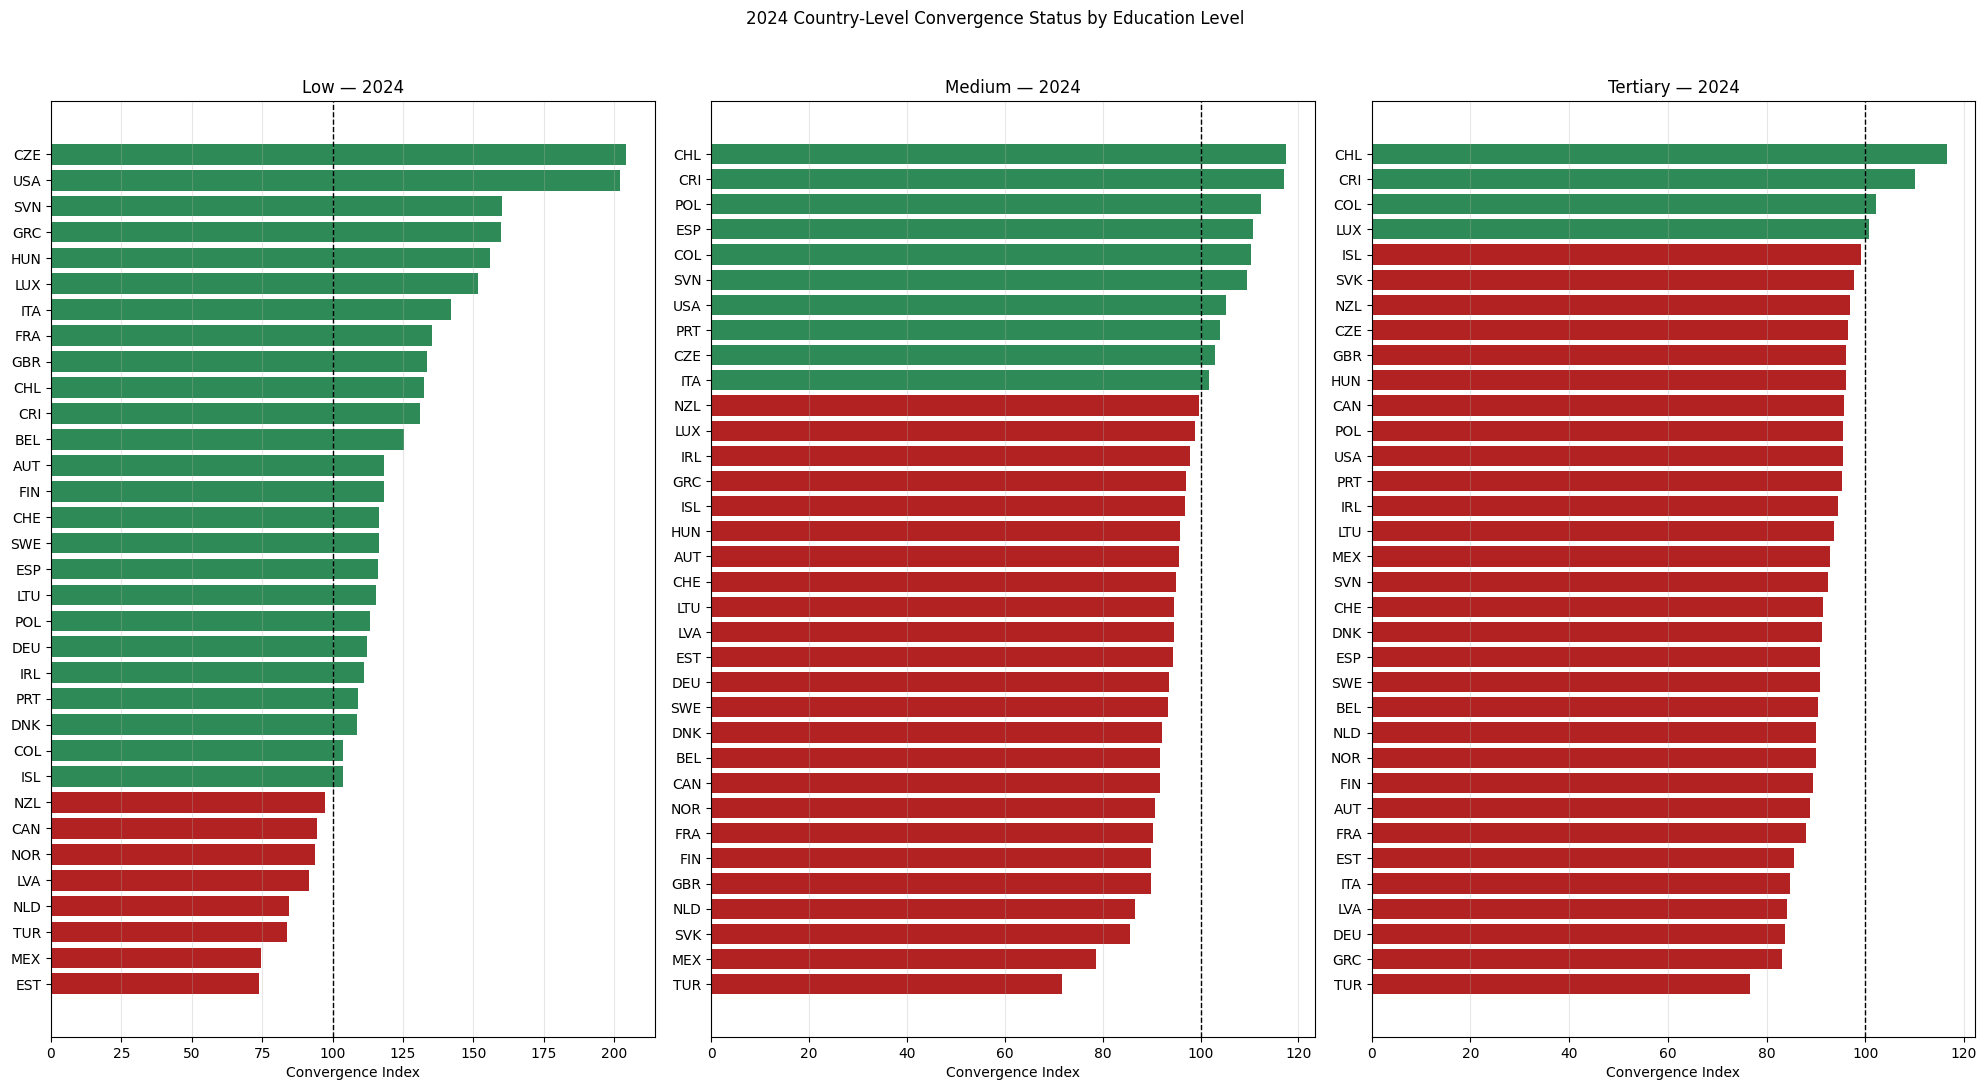

Methodology — Chart 3:
Each panel shows the 2024 convergence index by country for one education level.
Countries with a missing or undefined index value for 2024 are excluded from the
chart entirely (not shown as 0), so the bars reflect only countries with valid data.
Low: 33 out of 38 total countries shown.
Medium: 34 out of 38 total countries shown.
Tertiary: 34 out of 38 total countries shown.


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 0. YEAR FILTER AND CATEGORIES
# ============================================================

result["TIME_PERIOD"] = result["TIME_PERIOD"].astype(int)
res = result[(result["TIME_PERIOD"] >= 2015) & (result["TIME_PERIOD"] <= 2024)].copy()

categories = ["Low", "Medium", "Tertiary"]
colors_map = {"Low": "tab:blue", "Medium": "tab:orange", "Tertiary": "tab:green"}

# ============================================================
# 1. CHART: FOREIGN vs NATIVE TREND FOR EACH EDUCATION LEVEL (3 panels)
# NaNs are automatically excluded inside groupby().mean() (skipna=True)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
coverage_trend = {}

for ax, cat in zip(axes, categories):
    f_col, n_col = f"{cat}_Foreign", f"{cat}_Native"
    yearly = res.groupby("TIME_PERIOD")[[f_col, n_col]].mean()
    coverage_trend[cat] = res.groupby("TIME_PERIOD")[[f_col, n_col]].apply(lambda d: d.notna().sum())

    ax.plot(yearly.index, yearly[f_col], marker="o", label="Foreign-born")
    ax.plot(yearly.index, yearly[n_col], marker="o", label="Native-born")
    ax.set_title(f"{cat} Education Level")
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

axes[0].set_ylabel("Employment Rate (%)")
fig.suptitle("Foreign-born vs Native-born Employment Rate by Education Level (2015-2024)", y=1.03)
plt.tight_layout()
plt.show()

print("Methodology — Chart 1:")
print("For each education level and year, the employment rate is averaged across all")
print("countries that reported a value for that year. pandas' .mean() ignores NaN by")
print("default (skipna=True), so a country missing data for a given year/category is")
print("simply left out of that year's average rather than treated as zero.")
print("Countries contributing per year (per category):")
for cat in categories:
    print(f"\n{cat}:")
    print(coverage_trend[cat])
print()

# ============================================================
# 2. CONVERGENCE INDEX FOR EACH EDUCATION LEVEL (Foreign/Native * 100)
# NOTE: if Native = 0 or NaN, the ratio becomes undefined (NaN/inf).
# These cases are explicitly converted to NaN and excluded before
# averaging, so they cannot bias the index.
# ============================================================

index_by_year = {}
coverage_by_year = {}

for cat in categories:
    f_col, n_col = f"{cat}_Foreign", f"{cat}_Native"
    idx_col = f"{cat}_Index"

    # ratio is undefined when Native is 0 -> convert to NaN
    ratio = res[f_col] / res[n_col].replace(0, np.nan)
    ratio = ratio.replace([np.inf, -np.inf], np.nan)
    res[idx_col] = ratio * 100

    index_by_year[cat] = res.groupby("TIME_PERIOD")[idx_col].mean()
    coverage_by_year[cat] = res.groupby("TIME_PERIOD")[idx_col].apply(lambda s: s.notna().sum())

plt.figure(figsize=(10, 6))
for cat in categories:
    plt.plot(index_by_year[cat].index, index_by_year[cat].values,
              marker="o", label=f"{cat}", color=colors_map[cat])
plt.axhline(100, color="gray", linestyle="--", linewidth=1, label="Full Convergence (100)")
plt.title("Convergence Index by Education Level (Average Across Countries, 2015-2024)")
plt.xlabel("Year")
plt.ylabel("Convergence Index (Foreign/Native × 100)")
plt.legend(title="Education Level")
plt.grid(alpha=0.3)
plt.xticks(index_by_year["Low"].index, rotation=45)
plt.tight_layout()
plt.show()

coverage_df = pd.DataFrame(coverage_by_year)
print("Methodology — Chart 2:")
print("The convergence index is computed per country-year-category as")
print("(Foreign / Native) * 100. Rows where Native is 0 or NaN produce an undefined")
print("ratio; these are converted to NaN and dropped before averaging, so they do not")
print("distort the yearly mean. Each plotted line is the mean of the index across all")
print("countries with a valid value in that year, for that education level.")
print("Number of countries contributing to the index, per year and category:")
print(coverage_df)
print()

# ============================================================
# 3. 2024: CONVERGENCE INDEX BY COUNTRY FOR EACH EDUCATION LEVEL
# (3 horizontal bar charts). Countries with no valid 2024 index
# value are dropped rather than shown as zero.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, max(6, res["REF_AREA"].nunique() * 0.28)))
counts_2024 = {}

for ax, cat in zip(axes, categories):
    idx_col = f"{cat}_Index"
    data_2024 = res[res["TIME_PERIOD"] == 2024][["REF_AREA", idx_col]].dropna()
    data_2024 = data_2024.sort_values(idx_col)
    counts_2024[cat] = len(data_2024)

    bar_colors = ["firebrick" if v < 100 else "seagreen" for v in data_2024[idx_col]]
    ax.barh(data_2024["REF_AREA"], data_2024[idx_col], color=bar_colors)
    ax.axvline(100, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{cat} — 2024")
    ax.set_xlabel("Convergence Index")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("2024 Country-Level Convergence Status by Education Level", y=1.02)
plt.tight_layout()
plt.show()

print("Methodology — Chart 3:")
print("Each panel shows the 2024 convergence index by country for one education level.")
print("Countries with a missing or undefined index value for 2024 are excluded from the")
print("chart entirely (not shown as 0), so the bars reflect only countries with valid data.")
total_countries = res["REF_AREA"].nunique()
for cat in categories:
    print(f"{cat}: {counts_2024[cat]} out of {total_countries} total countries shown.")


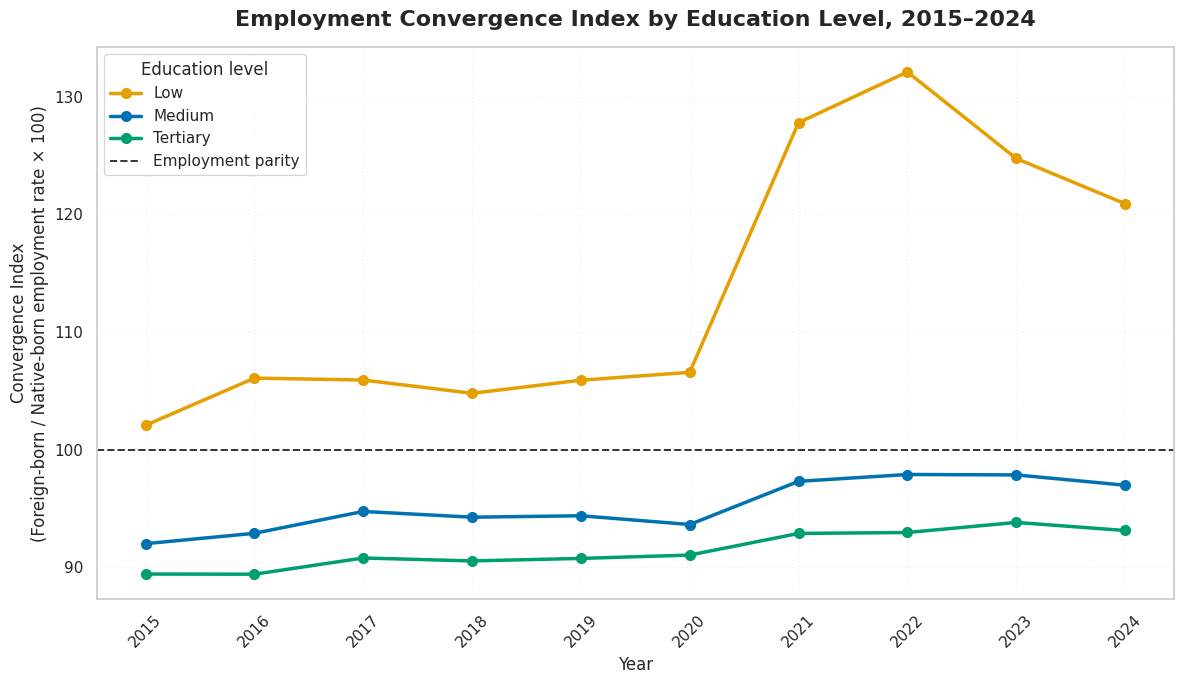

Number of countries included in each annual average:


,TIME_PERIOD,Low,Medium,Tertiary
0,2015,28,31,31
1,2016,28,30,30
2,2017,28,30,30
3,2018,27,29,29
4,2019,28,30,30
5,2020,31,33,33
6,2021,30,32,32
7,2022,28,29,29
8,2023,29,34,34
9,2024,33,34,34


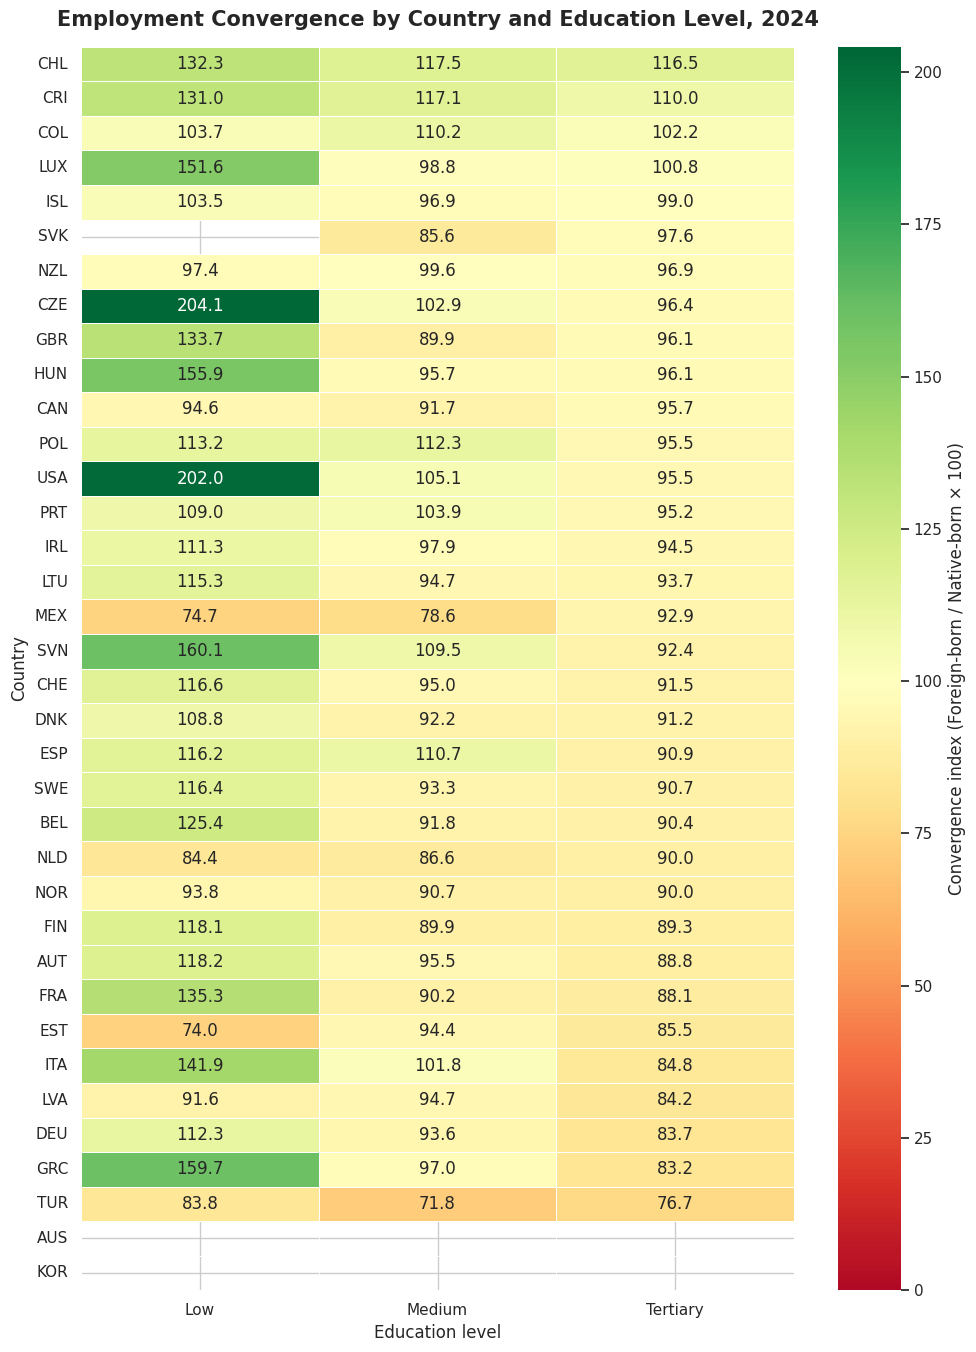

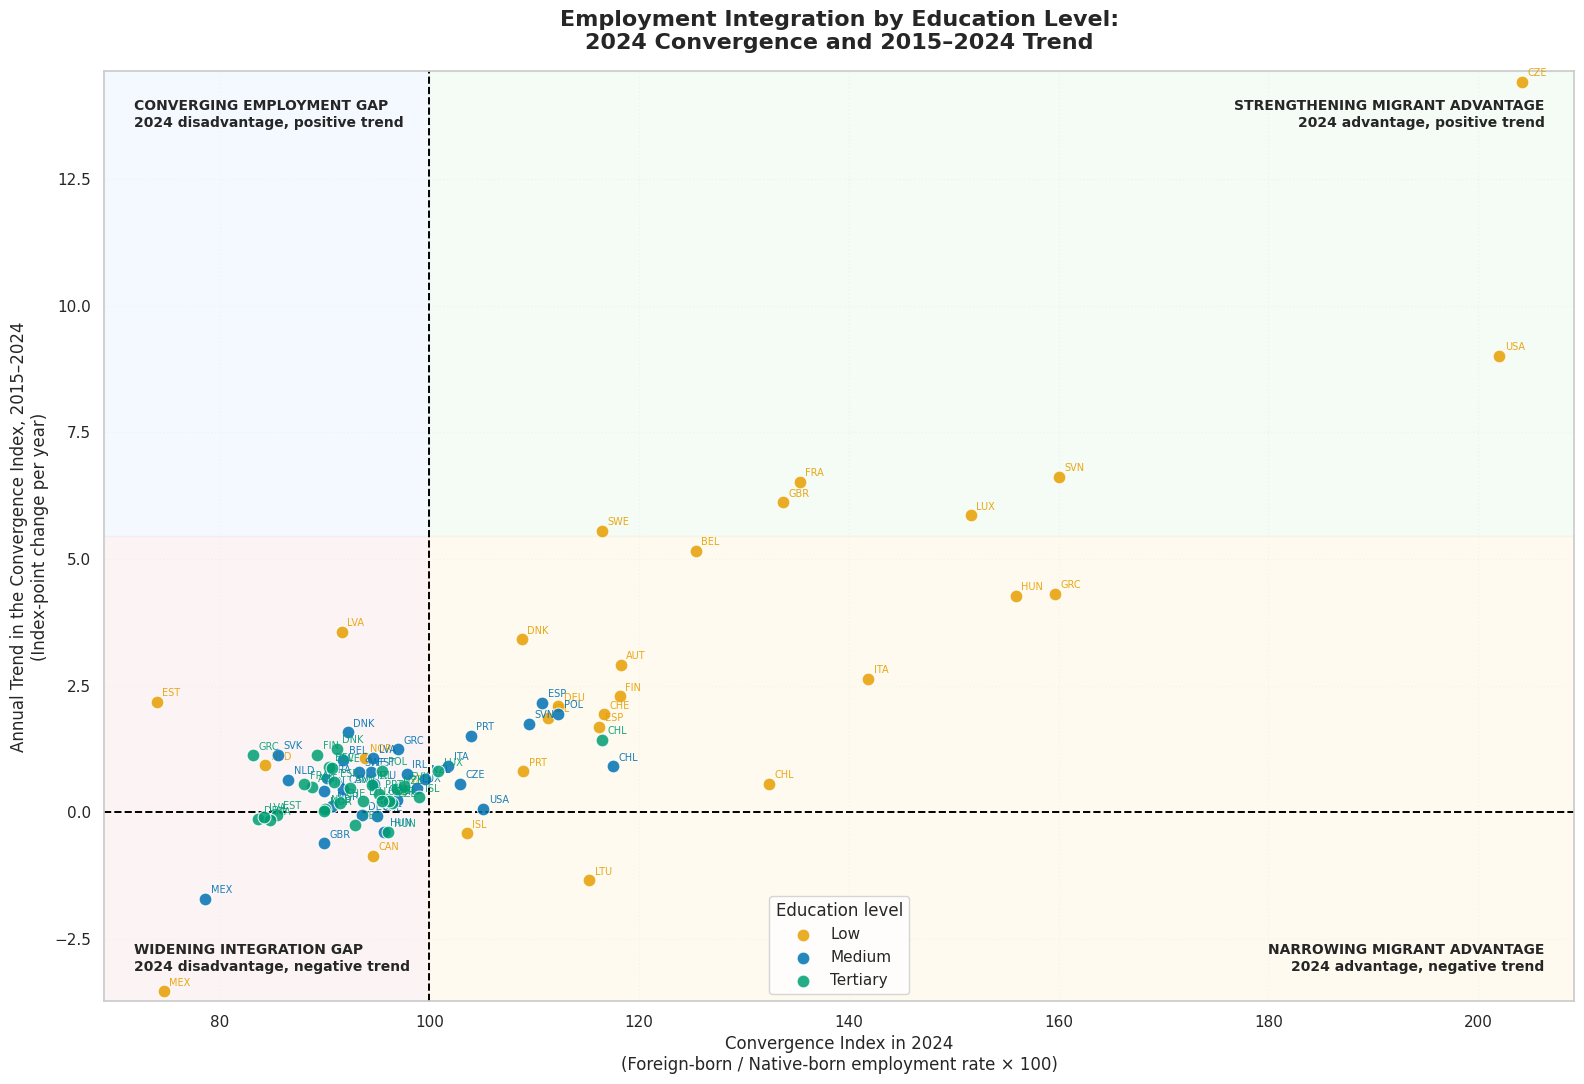

,Country,Education level,Convergence index (2024),Annual trend (2015–2024),Years available,Integration position
0,AUT,Low,118.2,2.91,10,Strengthening migrant advantage
1,AUT,Medium,95.5,0.27,10,Converging employment gap
2,AUT,Tertiary,88.8,0.50,10,Converging employment gap
3,BEL,Low,125.4,5.16,10,Strengthening migrant advantage
4,BEL,Medium,91.8,1.04,10,Converging employment gap
...,...,...,...,...,...,...
86,SWE,Medium,93.3,0.80,10,Converging employment gap
87,SWE,Tertiary,90.7,0.88,10,Converging employment gap
88,USA,Low,202.0,9.01,10,Strengthening migrant advantage
89,USA,Medium,105.1,0.07,10,Strengthening migrant advantage


,Education,Country_Type,Number of countries
0,Low,Converging employment gap,5
1,Low,Narrowing migrant advantage,2
2,Low,Strengthening migrant advantage,20
3,Low,Widening integration gap,2
4,Medium,Converging employment gap,18
5,Medium,Strengthening migrant advantage,8
6,Medium,Widening integration gap,5
7,Tertiary,Converging employment gap,23
8,Tertiary,Strengthening migrant advantage,2
9,Tertiary,Widening integration gap,6


Excel file created: education_convergence_typology_2015_2024.xlsx


In [6]:
# ============================================================
# EMPLOYMENT CONVERGENCE BY EDUCATION LEVEL
# 2015–2024
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Education levels and chart colors
education_levels = {
    "Low": {
        "foreign": "Low_Foreign",
        "native": "Low_Native",
        "color": "#E69F00"
    },
    "Medium": {
        "foreign": "Medium_Foreign",
        "native": "Medium_Native",
        "color": "#0072B2"
    },
    "Tertiary": {
        "foreign": "Tertiary_Foreign",
        "native": "Tertiary_Native",
        "color": "#009E73"
    }
}

analysis_data = res.copy()

analysis_data["TIME_PERIOD"] = pd.to_numeric(
    analysis_data["TIME_PERIOD"],
    errors="coerce"
)

# Ensure that employment variables are numeric
employment_columns = []

for level, variables in education_levels.items():
    employment_columns.extend([
        variables["foreign"],
        variables["native"]
    ])

for column in employment_columns:
    analysis_data[column] = pd.to_numeric(
        analysis_data[column],
        errors="coerce"
    )

# ============================================================
# 1. CALCULATE COUNTRY-YEAR CONVERGENCE INDICES
# ============================================================

for level, variables in education_levels.items():

    foreign_column = variables["foreign"]
    native_column = variables["native"]
    index_column = f"{level}_Index"

    analysis_data[index_column] = np.where(
        analysis_data[native_column] > 0,
        analysis_data[foreign_column] /
        analysis_data[native_column] * 100,
        np.nan
    )

index_columns = [
    "Low_Index",
    "Medium_Index",
    "Tertiary_Index"
]

analysis_data[index_columns] = (
    analysis_data[index_columns]
    .replace([np.inf, -np.inf], np.nan)
)

# ============================================================
# GRAPH 1
# AVERAGE CONVERGENCE INDEX, 2015–2024
# ============================================================

yearly_indices = (
    analysis_data
    .groupby("TIME_PERIOD")[index_columns]
    .mean()
    .reset_index()
)

yearly_coverage = (
    analysis_data
    .groupby("TIME_PERIOD")[index_columns]
    .count()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

for level, variables in education_levels.items():

    ax.plot(
        yearly_indices["TIME_PERIOD"],
        yearly_indices[f"{level}_Index"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=variables["color"],
        label=level
    )

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.4,
    alpha=0.8,
    label="Employment parity"
)

ax.set_title(
    "Employment Convergence Index by Education Level, 2015–2024",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel(
    "Convergence Index\n"
    "(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)

ax.set_xticks(yearly_indices["TIME_PERIOD"])
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Education level",
    frameon=True
)

ax.grid(alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

print("Number of countries included in each annual average:")
display(
    yearly_coverage.rename(
        columns={
            "Low_Index": "Low",
            "Medium_Index": "Medium",
            "Tertiary_Index": "Tertiary"
        }
    )
)

# ============================================================
# GRAPH 2
# COUNTRY-LEVEL CONVERGENCE INDICES IN 2024
# ============================================================

data_2024 = (
    analysis_data[
        analysis_data["TIME_PERIOD"] == 2024
    ][
        ["REF_AREA"] + index_columns
    ]
    .drop_duplicates(subset=["REF_AREA"])
    .set_index("REF_AREA")
)

# Sort countries by their tertiary education index
data_2024 = data_2024.sort_values(
    "Tertiary_Index",
    ascending=False
)

# Use symmetric limits around 100 so that advantage and
# disadvantage receive comparable visual weight
available_values = data_2024.to_numpy().flatten()
available_values = available_values[~np.isnan(available_values)]

maximum_distance = max(
    abs(available_values.min() - 100),
    abs(available_values.max() - 100)
)

heatmap_min = max(0, 100 - maximum_distance)
heatmap_max = 100 + maximum_distance

fig_height = max(9, len(data_2024) * 0.38)

fig, ax = plt.subplots(
    figsize=(10, fig_height)
)

sns.heatmap(
    data_2024,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=100,
    vmin=heatmap_min,
    vmax=heatmap_max,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label":
        "Convergence index "
        "(Foreign-born / Native-born × 100)"
    },
    ax=ax
)

ax.set_title(
    "Employment Convergence by Country and Education Level, 2024",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Education level", fontsize=12)
ax.set_ylabel("Country", fontsize=12)

ax.set_xticklabels(
    ["Low", "Medium", "Tertiary"],
    rotation=0
)

plt.tight_layout()
plt.show()

# ============================================================
# 3. ESTIMATE 2015–2024 TRENDS FOR EACH COUNTRY AND
#    EDUCATION LEVEL
# ============================================================

trend_records = []

for country, country_data in analysis_data.groupby("REF_AREA"):

    for level in education_levels.keys():

        index_column = f"{level}_Index"

        level_data = (
            country_data[
                ["TIME_PERIOD", index_column]
            ]
            .dropna()
            .drop_duplicates(subset=["TIME_PERIOD"])
            .sort_values("TIME_PERIOD")
        )

        number_of_years = level_data[
            "TIME_PERIOD"
        ].nunique()

        # Require at least five annual observations
        if number_of_years < 5:
            continue

        slope = np.polyfit(
            level_data["TIME_PERIOD"],
            level_data[index_column],
            1
        )[0]

        level_2024 = level_data.loc[
            level_data["TIME_PERIOD"] == 2024,
            index_column
        ]

        # A 2024 observation is necessary for the quadrant chart
        if level_2024.empty:
            continue

        trend_records.append({
            "Country": country,
            "Education": level,
            "Convergence_2024": level_2024.iloc[0],
            "Trend_2015_2024": slope,
            "Years_Available": number_of_years
        })

quadrant_data = pd.DataFrame(trend_records)

# ============================================================
# 4. CLASSIFY EVERY COUNTRY-EDUCATION OBSERVATION
# ============================================================

def classify_position(row):

    level = row["Convergence_2024"]
    trend = row["Trend_2015_2024"]

    if level >= 100 and trend >= 0:
        return "Strengthening migrant advantage"

    elif level >= 100 and trend < 0:
        return "Narrowing migrant advantage"

    elif level < 100 and trend >= 0:
        return "Converging employment gap"

    else:
        return "Widening integration gap"


quadrant_data["Country_Type"] = quadrant_data.apply(
    classify_position,
    axis=1
)

# ============================================================
# GRAPH 3
# FOUR-QUADRANT CHART WITH THREE EDUCATION COLORS
# ============================================================

fig, ax = plt.subplots(figsize=(16, 11))

# Light background shading for the four regions
x_min = min(
    quadrant_data["Convergence_2024"].min() - 5,
    90
)

x_max = max(
    quadrant_data["Convergence_2024"].max() + 5,
    110
)

y_min = min(
    quadrant_data["Trend_2015_2024"].min() - 0.2,
    -1
)

y_max = max(
    quadrant_data["Trend_2015_2024"].max() + 0.2,
    1
)

ax.axvspan(
    x_min, 100,
    ymin=0.5,
    ymax=1,
    color="#DCEEFF",
    alpha=0.30
)

ax.axvspan(
    100, x_max,
    ymin=0.5,
    ymax=1,
    color="#DFF2E1",
    alpha=0.30
)

ax.axvspan(
    x_min, 100,
    ymin=0,
    ymax=0.5,
    color="#F8DDDD",
    alpha=0.30
)

ax.axvspan(
    100, x_max,
    ymin=0,
    ymax=0.5,
    color="#FFF0CC",
    alpha=0.30
)

for level, variables in education_levels.items():

    group = quadrant_data[
        quadrant_data["Education"] == level
    ]

    ax.scatter(
        group["Convergence_2024"],
        group["Trend_2015_2024"],
        s=85,
        color=variables["color"],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85,
        label=level,
        zorder=3
    )

    for _, row in group.iterrows():

        ax.annotate(
            row["Country"],
            (
                row["Convergence_2024"],
                row["Trend_2015_2024"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
            color=variables["color"],
            alpha=0.90
        )

ax.axvline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.4
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.4
)

# Quadrant labels
ax.text(
    0.02, 0.97,
    "CONVERGING EMPLOYMENT GAP\n"
    "2024 disadvantage, positive trend",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    0.98, 0.97,
    "STRENGTHENING MIGRANT ADVANTAGE\n"
    "2024 advantage, positive trend",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    0.02, 0.03,
    "WIDENING INTEGRATION GAP\n"
    "2024 disadvantage, negative trend",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

ax.text(
    0.98, 0.03,
    "NARROWING MIGRANT ADVANTAGE\n"
    "2024 advantage, negative trend",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    fontweight="bold"
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Employment Integration by Education Level:\n"
    "2024 Convergence and 2015–2024 Trend",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Convergence Index in 2024\n"
    "(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)

ax.set_ylabel(
    "Annual Trend in the Convergence Index, 2015–2024\n"
    "(Index-point change per year)",
    fontsize=12
)

ax.legend(
    title="Education level",
    loc="best",
    frameon=True
)

ax.grid(alpha=0.18, linestyle=":")

plt.tight_layout()
plt.show()

# ============================================================
# 5. COUNTRY-LEVEL RESULTS TABLE
# ============================================================

country_results = (
    quadrant_data[
        [
            "Country",
            "Education",
            "Convergence_2024",
            "Trend_2015_2024",
            "Years_Available",
            "Country_Type"
        ]
    ]
    .sort_values(
        ["Country", "Education"]
    )
    .reset_index(drop=True)
)

country_results["Convergence_2024"] = (
    country_results["Convergence_2024"].round(1)
)

country_results["Trend_2015_2024"] = (
    country_results["Trend_2015_2024"].round(2)
)

display(
    country_results.rename(
        columns={
            "Country": "Country",
            "Education": "Education level",
            "Convergence_2024": "Convergence index (2024)",
            "Trend_2015_2024": "Annual trend (2015–2024)",
            "Years_Available": "Years available",
            "Country_Type": "Integration position"
        }
    )
)

# Summary table
summary_table = (
    quadrant_data
    .groupby(
        ["Education", "Country_Type"]
    )
    .size()
    .reset_index(name="Number of countries")
)

display(summary_table)

# ============================================================
# 6. OPTIONAL DOWNLOAD
# ============================================================

output_file = "education_convergence_typology_2015_2024.xlsx"

with pd.ExcelWriter(output_file) as writer:

    yearly_indices.to_excel(
        writer,
        sheet_name="Annual averages",
        index=False
    )

    data_2024.reset_index().to_excel(
        writer,
        sheet_name="Country indices 2024",
        index=False
    )

    country_results.to_excel(
        writer,
        sheet_name="Country typology",
        index=False
    )

    summary_table.to_excel(
        writer,
        sheet_name="Summary",
        index=False
    )

print(f"Excel file created: {output_file}")

# Uncomment in Google Colab if you want to download the file:
# files.download(output_file)

Countries missing a population weight for at least one year: ['CAN', 'COL', 'CRI', 'GBR', 'GRC', 'HRV', 'IRL', 'KOR', 'MEX', 'NZL', 'POL', 'PRT']


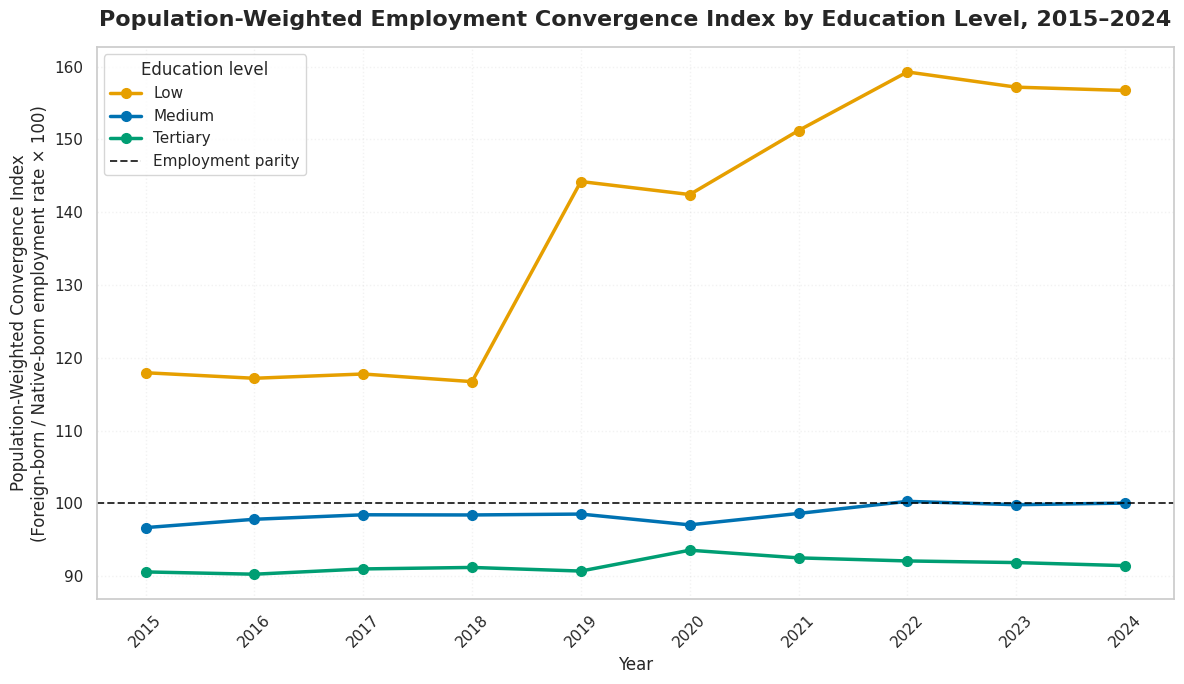

Methodology — Graph 1 (Population-Weighted Index):
Each country's weight equals its share of the total foreign-born population
(BIRTH_COUNTRY='W' in the OECD DF_MIG_POPF dataflow) among countries with valid
index data that year; weights are recomputed annually. This reflects the experience
of a 'typical migrant' in the sample rather than a 'typical country'.

Number of countries included in each annual average (unweighted count, for reference):


,TIME_PERIOD,Low,Medium,Tertiary
0,2015,28,31,31
1,2016,28,30,30
2,2017,28,30,30
3,2018,27,29,29
4,2019,28,30,30
5,2020,31,33,33
6,2021,30,32,32
7,2022,28,29,29
8,2023,29,34,34
9,2024,33,34,34


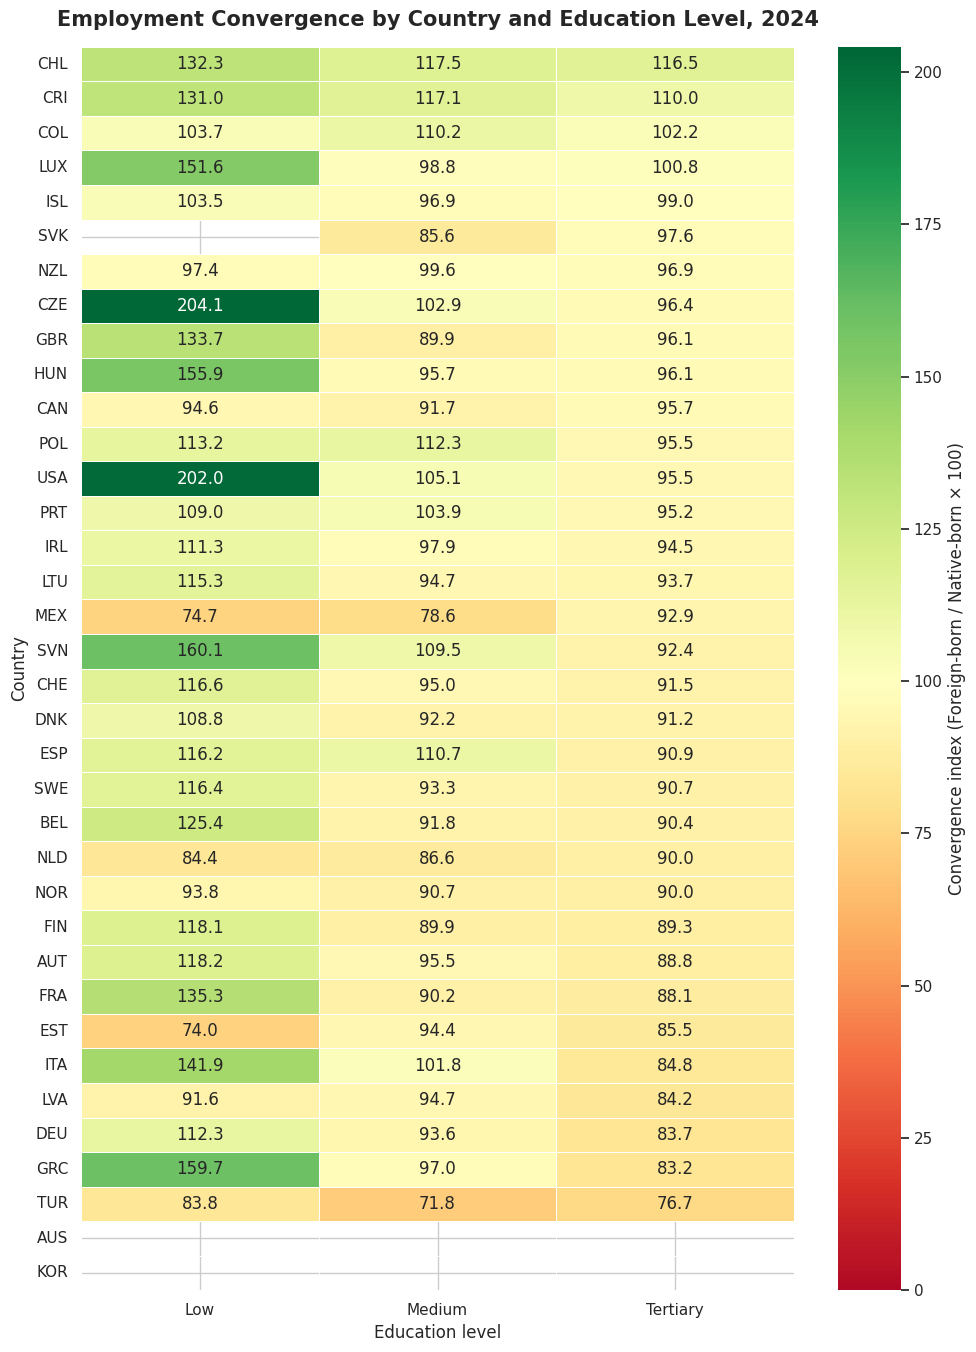

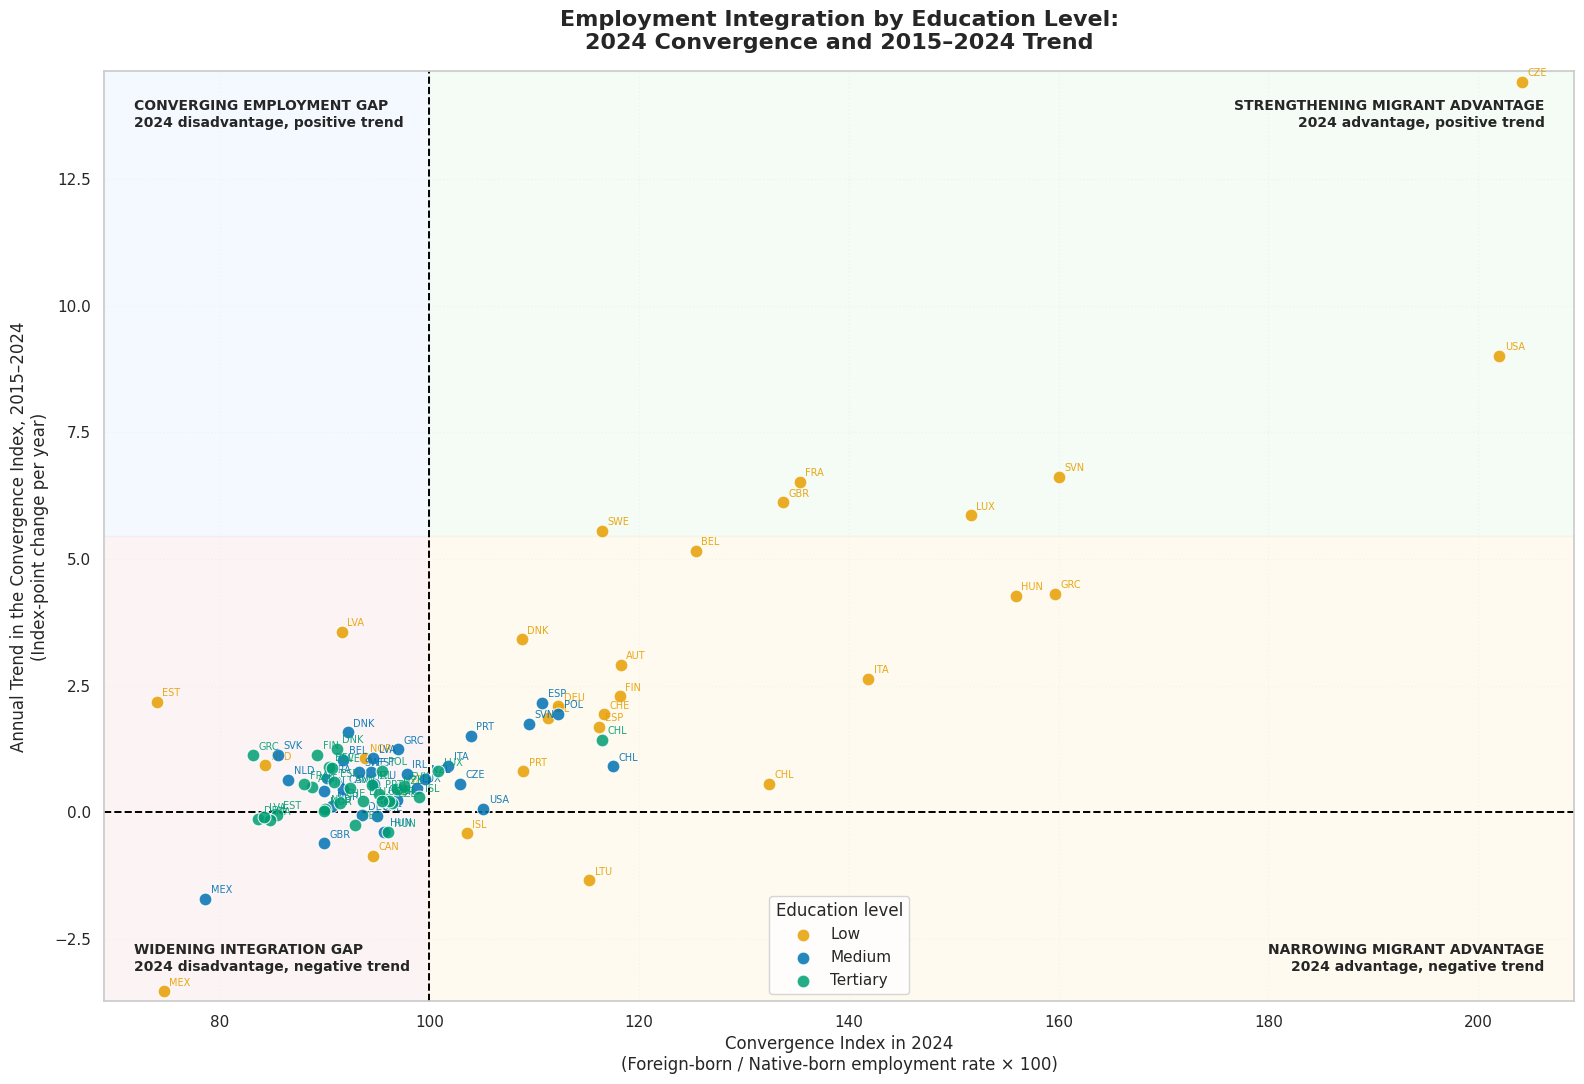

,Country,Education level,Convergence index (2024),Annual trend (2015–2024),Years available,Integration position
0,AUT,Low,118.2,2.91,10,Strengthening migrant advantage
1,AUT,Medium,95.5,0.27,10,Converging employment gap
2,AUT,Tertiary,88.8,0.50,10,Converging employment gap
3,BEL,Low,125.4,5.16,10,Strengthening migrant advantage
4,BEL,Medium,91.8,1.04,10,Converging employment gap
...,...,...,...,...,...,...
86,SWE,Medium,93.3,0.80,10,Converging employment gap
87,SWE,Tertiary,90.7,0.88,10,Converging employment gap
88,USA,Low,202.0,9.01,10,Strengthening migrant advantage
89,USA,Medium,105.1,0.07,10,Strengthening migrant advantage


,Education,Country_Type,Number of countries
0,Low,Converging employment gap,5
1,Low,Narrowing migrant advantage,2
2,Low,Strengthening migrant advantage,20
3,Low,Widening integration gap,2
4,Medium,Converging employment gap,18
5,Medium,Strengthening migrant advantage,8
6,Medium,Widening integration gap,5
7,Tertiary,Converging employment gap,23
8,Tertiary,Strengthening migrant advantage,2
9,Tertiary,Widening integration gap,6


Excel file created: education_convergence_typology_2015_2024_weighted.xlsx


In [7]:
# ============================================================
# EMPLOYMENT CONVERGENCE BY EDUCATION LEVEL (POPULATION-WEIGHTED)
# 2015–2024
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Education levels and chart colors
education_levels = {
    "Low": {
        "foreign": "Low_Foreign",
        "native": "Low_Native",
        "color": "#E69F00"
    },
    "Medium": {
        "foreign": "Medium_Foreign",
        "native": "Medium_Native",
        "color": "#0072B2"
    },
    "Tertiary": {
        "foreign": "Tertiary_Foreign",
        "native": "Tertiary_Native",
        "color": "#009E73"
    }
}

analysis_data = res.copy()

analysis_data["TIME_PERIOD"] = pd.to_numeric(
    analysis_data["TIME_PERIOD"],
    errors="coerce"
)

# Ensure that employment variables are numeric
employment_columns = []

for level, variables in education_levels.items():
    employment_columns.extend([
        variables["foreign"],
        variables["native"]
    ])

for column in employment_columns:
    analysis_data[column] = pd.to_numeric(
        analysis_data[column],
        errors="coerce"
    )

# ============================================================
# 1. CALCULATE COUNTRY-YEAR CONVERGENCE INDICES
# ============================================================

for level, variables in education_levels.items():

    foreign_column = variables["foreign"]
    native_column = variables["native"]
    index_column = f"{level}_Index"

    analysis_data[index_column] = np.where(
        analysis_data[native_column] > 0,
        analysis_data[foreign_column] /
        analysis_data[native_column] * 100,
        np.nan
    )

index_columns = [
    "Low_Index",
    "Medium_Index",
    "Tertiary_Index"
]

analysis_data[index_columns] = (
    analysis_data[index_columns]
    .replace([np.inf, -np.inf], np.nan)
)

# ============================================================
# 1B. MERGE FOREIGN-BORN POPULATION WEIGHTS
# Assumes `foreign_pop` (REF_AREA, TIME_PERIOD, Foreign_Born_Population)
# was already built earlier from DF_MIG_POPF (BIRTH_COUNTRY="W").
# Run that block first if `foreign_pop` is not yet in memory.
# ============================================================

analysis_data["TIME_PERIOD"] = analysis_data["TIME_PERIOD"].astype(int)
foreign_pop["TIME_PERIOD"] = foreign_pop["TIME_PERIOD"].astype(int)

analysis_data = analysis_data.merge(
    foreign_pop,
    on=["REF_AREA", "TIME_PERIOD"],
    how="left"
)

missing_weight_countries = sorted(
    analysis_data.loc[
        analysis_data["Foreign_Born_Population"].isna(), "REF_AREA"
    ].unique()
)
print(f"Countries missing a population weight for at least one year: {missing_weight_countries}")


def weighted_avg_by_year(df, value_col, weight_col, year_col="TIME_PERIOD"):
    out = {}
    for year, group in df.groupby(year_col):
        valid = group.dropna(subset=[value_col, weight_col])
        valid = valid[valid[weight_col] > 0]
        if len(valid) == 0 or valid[weight_col].sum() == 0:
            out[year] = np.nan
            continue
        out[year] = np.average(valid[value_col], weights=valid[weight_col])
    return pd.Series(out).sort_index()

# ============================================================
# GRAPH 1
# POPULATION-WEIGHTED AVERAGE CONVERGENCE INDEX, 2015–2024
# ============================================================

yearly_indices = pd.DataFrame({
    level: weighted_avg_by_year(analysis_data, f"{level}_Index", "Foreign_Born_Population")
    for level in education_levels.keys()
}).reset_index().rename(columns={"index": "TIME_PERIOD"})

yearly_coverage = (
    analysis_data
    .groupby("TIME_PERIOD")[index_columns]
    .count()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))

for level, variables in education_levels.items():

    ax.plot(
        yearly_indices["TIME_PERIOD"],
        yearly_indices[level],
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=variables["color"],
        label=level
    )

ax.axhline(
    100,
    color="black",
    linestyle="--",
    linewidth=1.4,
    alpha=0.8,
    label="Employment parity"
)

ax.set_title(
    "Population-Weighted Employment Convergence Index by Education Level, 2015–2024",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel(
    "Population-Weighted Convergence Index\n"
    "(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)

ax.set_xticks(yearly_indices["TIME_PERIOD"])
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Education level",
    frameon=True
)

ax.grid(alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

print("Methodology — Graph 1 (Population-Weighted Index):")
print("Each country's weight equals its share of the total foreign-born population")
print("(BIRTH_COUNTRY='W' in the OECD DF_MIG_POPF dataflow) among countries with valid")
print("index data that year; weights are recomputed annually. This reflects the experience")
print("of a 'typical migrant' in the sample rather than a 'typical country'.")
print("\nNumber of countries included in each annual average (unweighted count, for reference):")
display(
    yearly_coverage.rename(
        columns={
            "Low_Index": "Low",
            "Medium_Index": "Medium",
            "Tertiary_Index": "Tertiary"
        }
    )
)

# ============================================================
# GRAPH 2
# COUNTRY-LEVEL CONVERGENCE INDICES IN 2024
# (unaffected by weighting — this shows each country's own value,
# not a cross-country aggregate)
# ============================================================

data_2024 = (
    analysis_data[
        analysis_data["TIME_PERIOD"] == 2024
    ][
        ["REF_AREA"] + index_columns
    ]
    .drop_duplicates(subset=["REF_AREA"])
    .set_index("REF_AREA")
)

# Sort countries by their tertiary education index
data_2024 = data_2024.sort_values(
    "Tertiary_Index",
    ascending=False
)

# Use symmetric limits around 100 so that advantage and
# disadvantage receive comparable visual weight
available_values = data_2024.to_numpy().flatten()
available_values = available_values[~np.isnan(available_values)]

maximum_distance = max(
    abs(available_values.min() - 100),
    abs(available_values.max() - 100)
)

heatmap_min = max(0, 100 - maximum_distance)
heatmap_max = 100 + maximum_distance

fig_height = max(9, len(data_2024) * 0.38)

fig, ax = plt.subplots(
    figsize=(10, fig_height)
)

sns.heatmap(
    data_2024,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn",
    center=100,
    vmin=heatmap_min,
    vmax=heatmap_max,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label":
        "Convergence index "
        "(Foreign-born / Native-born × 100)"
    },
    ax=ax
)

ax.set_title(
    "Employment Convergence by Country and Education Level, 2024",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Education level", fontsize=12)
ax.set_ylabel("Country", fontsize=12)

ax.set_xticklabels(
    ["Low", "Medium", "Tertiary"],
    rotation=0
)

plt.tight_layout()
plt.show()

# ============================================================
# 3. ESTIMATE 2015–2024 TRENDS FOR EACH COUNTRY AND
#    EDUCATION LEVEL
# (per-country OLS trend — weighting does not apply here, since
# each country's own trajectory is estimated independently)
# ============================================================

trend_records = []

for country, country_data in analysis_data.groupby("REF_AREA"):

    for level in education_levels.keys():

        index_column = f"{level}_Index"

        level_data = (
            country_data[
                ["TIME_PERIOD", index_column]
            ]
            .dropna()
            .drop_duplicates(subset=["TIME_PERIOD"])
            .sort_values("TIME_PERIOD")
        )

        number_of_years = level_data[
            "TIME_PERIOD"
        ].nunique()

        # Require at least five annual observations
        if number_of_years < 5:
            continue

        slope = np.polyfit(
            level_data["TIME_PERIOD"],
            level_data[index_column],
            1
        )[0]

        level_2024 = level_data.loc[
            level_data["TIME_PERIOD"] == 2024,
            index_column
        ]

        # A 2024 observation is necessary for the quadrant chart
        if level_2024.empty:
            continue

        trend_records.append({
            "Country": country,
            "Education": level,
            "Convergence_2024": level_2024.iloc[0],
            "Trend_2015_2024": slope,
            "Years_Available": number_of_years
        })

quadrant_data = pd.DataFrame(trend_records)

# ============================================================
# 4. CLASSIFY EVERY COUNTRY-EDUCATION OBSERVATION
# ============================================================

def classify_position(row):

    level = row["Convergence_2024"]
    trend = row["Trend_2015_2024"]

    if level >= 100 and trend >= 0:
        return "Strengthening migrant advantage"

    elif level >= 100 and trend < 0:
        return "Narrowing migrant advantage"

    elif level < 100 and trend >= 0:
        return "Converging employment gap"

    else:
        return "Widening integration gap"


quadrant_data["Country_Type"] = quadrant_data.apply(
    classify_position,
    axis=1
)

# ============================================================
# GRAPH 3
# FOUR-QUADRANT CHART WITH THREE EDUCATION COLORS
# ============================================================

fig, ax = plt.subplots(figsize=(16, 11))

x_min = min(quadrant_data["Convergence_2024"].min() - 5, 90)
x_max = max(quadrant_data["Convergence_2024"].max() + 5, 110)
y_min = min(quadrant_data["Trend_2015_2024"].min() - 0.2, -1)
y_max = max(quadrant_data["Trend_2015_2024"].max() + 0.2, 1)

ax.axvspan(x_min, 100, ymin=0.5, ymax=1, color="#DCEEFF", alpha=0.30)
ax.axvspan(100, x_max, ymin=0.5, ymax=1, color="#DFF2E1", alpha=0.30)
ax.axvspan(x_min, 100, ymin=0, ymax=0.5, color="#F8DDDD", alpha=0.30)
ax.axvspan(100, x_max, ymin=0, ymax=0.5, color="#FFF0CC", alpha=0.30)

for level, variables in education_levels.items():

    group = quadrant_data[quadrant_data["Education"] == level]

    ax.scatter(
        group["Convergence_2024"],
        group["Trend_2015_2024"],
        s=85,
        color=variables["color"],
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85,
        label=level,
        zorder=3
    )

    for _, row in group.iterrows():
        ax.annotate(
            row["Country"],
            (row["Convergence_2024"], row["Trend_2015_2024"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
            color=variables["color"],
            alpha=0.90
        )

ax.axvline(100, color="black", linestyle="--", linewidth=1.4)
ax.axhline(0, color="black", linestyle="--", linewidth=1.4)

ax.text(0.02, 0.97, "CONVERGING EMPLOYMENT GAP\n2024 disadvantage, positive trend",
        transform=ax.transAxes, ha="left", va="top", fontsize=10, fontweight="bold")
ax.text(0.98, 0.97, "STRENGTHENING MIGRANT ADVANTAGE\n2024 advantage, positive trend",
        transform=ax.transAxes, ha="right", va="top", fontsize=10, fontweight="bold")
ax.text(0.02, 0.03, "WIDENING INTEGRATION GAP\n2024 disadvantage, negative trend",
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10, fontweight="bold")
ax.text(0.98, 0.03, "NARROWING MIGRANT ADVANTAGE\n2024 advantage, negative trend",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_title(
    "Employment Integration by Education Level:\n2024 Convergence and 2015–2024 Trend",
    fontsize=16, fontweight="bold", pad=16
)
ax.set_xlabel(
    "Convergence Index in 2024\n(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)
ax.set_ylabel(
    "Annual Trend in the Convergence Index, 2015–2024\n(Index-point change per year)",
    fontsize=12
)
ax.legend(title="Education level", loc="best", frameon=True)
ax.grid(alpha=0.18, linestyle=":")

plt.tight_layout()
plt.show()

# ============================================================
# 5. COUNTRY-LEVEL RESULTS TABLE
# ============================================================

country_results = (
    quadrant_data[
        ["Country", "Education", "Convergence_2024", "Trend_2015_2024",
         "Years_Available", "Country_Type"]
    ]
    .sort_values(["Country", "Education"])
    .reset_index(drop=True)
)

country_results["Convergence_2024"] = country_results["Convergence_2024"].round(1)
country_results["Trend_2015_2024"] = country_results["Trend_2015_2024"].round(2)

display(
    country_results.rename(columns={
        "Country": "Country",
        "Education": "Education level",
        "Convergence_2024": "Convergence index (2024)",
        "Trend_2015_2024": "Annual trend (2015–2024)",
        "Years_Available": "Years available",
        "Country_Type": "Integration position"
    })
)

summary_table = (
    quadrant_data
    .groupby(["Education", "Country_Type"])
    .size()
    .reset_index(name="Number of countries")
)

display(summary_table)

# ============================================================
# 6. OPTIONAL DOWNLOAD
# ============================================================

output_file = "education_convergence_typology_2015_2024_weighted.xlsx"

with pd.ExcelWriter(output_file) as writer:
    yearly_indices.to_excel(writer, sheet_name="Weighted annual averages", index=False)
    data_2024.reset_index().to_excel(writer, sheet_name="Country indices 2024", index=False)
    country_results.to_excel(writer, sheet_name="Country typology", index=False)
    summary_table.to_excel(writer, sheet_name="Summary", index=False)

print(f"Excel file created: {output_file}")

# Uncomment in Google Colab if you want to download the file:
# files.download(output_file)

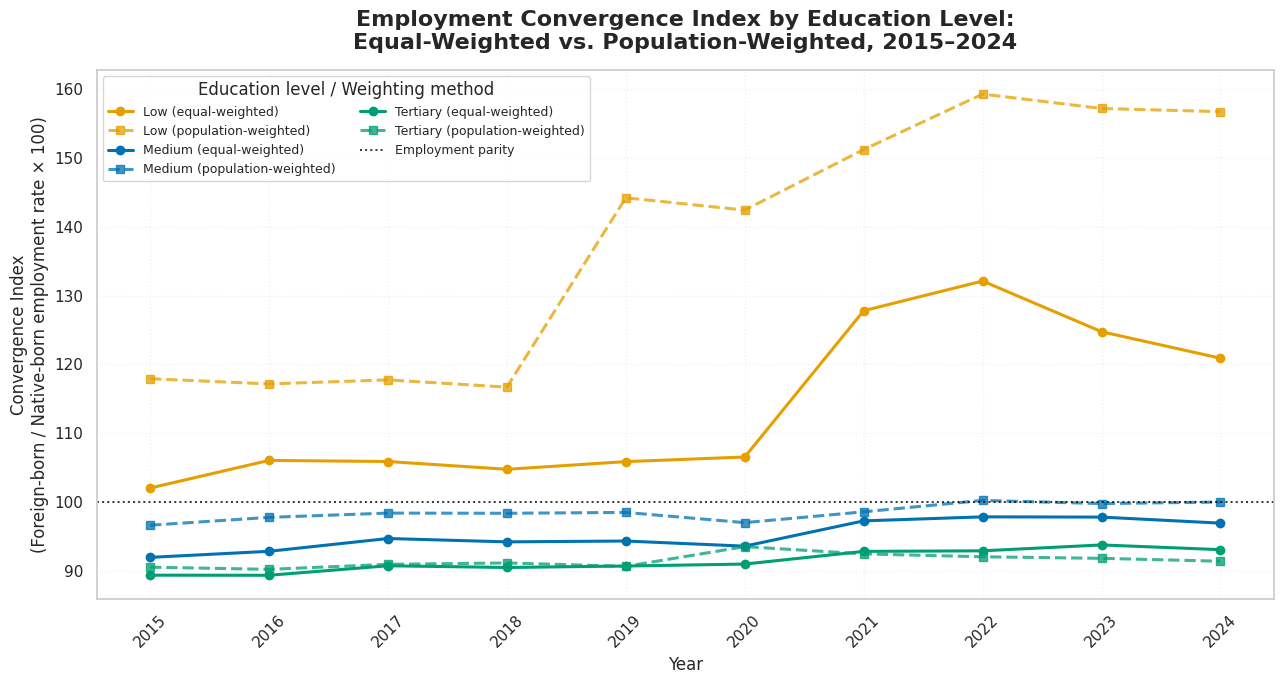

Methodology — Graph 1 (Equal-weighted vs. Population-weighted):
Solid lines show the equal-weighted average, where every country with a valid index
value contributes equally regardless of its migrant population size. Dashed lines show
the population-weighted average, where each country's weight equals its share of the
total foreign-born population (BIRTH_COUNTRY='W' in the OECD DF_MIG_POPF dataflow)
among countries with valid data that year; weights are recomputed annually. Divergence
between the two lines for a given education level indicates that large-immigration
countries have a systematically different convergence trajectory than small-immigration
countries for that level.


In [8]:
# ============================================================
# GRAPH 1
# EQUAL-WEIGHTED VS POPULATION-WEIGHTED CONVERGENCE INDEX
# BY EDUCATION LEVEL, 2015–2024
# ============================================================

equal_weighted_by_level = {
    level: analysis_data.groupby("TIME_PERIOD")[f"{level}_Index"].mean()
    for level in education_levels.keys()
}

pop_weighted_by_level = {
    level: weighted_avg_by_year(analysis_data, f"{level}_Index", "Foreign_Born_Population")
    for level in education_levels.keys()
}

fig, ax = plt.subplots(figsize=(13, 7))

for level, variables in education_levels.items():

    ax.plot(
        equal_weighted_by_level[level].index,
        equal_weighted_by_level[level].values,
        marker="o",
        markersize=6,
        linewidth=2.2,
        linestyle="-",
        color=variables["color"],
        label=f"{level} (equal-weighted)"
    )

    ax.plot(
        pop_weighted_by_level[level].index,
        pop_weighted_by_level[level].values,
        marker="s",
        markersize=6,
        linewidth=2.2,
        linestyle="--",
        color=variables["color"],
        alpha=0.75,
        label=f"{level} (population-weighted)"
    )

ax.axhline(
    100,
    color="black",
    linestyle=":",
    linewidth=1.4,
    alpha=0.8,
    label="Employment parity"
)

ax.set_title(
    "Employment Convergence Index by Education Level:\nEqual-Weighted vs. Population-Weighted, 2015–2024",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year", fontsize=12)

ax.set_ylabel(
    "Convergence Index\n(Foreign-born / Native-born employment rate × 100)",
    fontsize=12
)

ax.set_xticks(equal_weighted_by_level["Low"].index)
ax.tick_params(axis="x", rotation=45)

ax.legend(
    title="Education level / Weighting method",
    frameon=True,
    ncol=2,
    fontsize=9
)

ax.grid(alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

print("Methodology — Graph 1 (Equal-weighted vs. Population-weighted):")
print("Solid lines show the equal-weighted average, where every country with a valid index")
print("value contributes equally regardless of its migrant population size. Dashed lines show")
print("the population-weighted average, where each country's weight equals its share of the")
print("total foreign-born population (BIRTH_COUNTRY='W' in the OECD DF_MIG_POPF dataflow)")
print("among countries with valid data that year; weights are recomputed annually. Divergence")
print("between the two lines for a given education level indicates that large-immigration")
print("countries have a systematically different convergence trajectory than small-immigration")
print("countries for that level.")